## Modeling

## Project Objective
This notebook aims to find the best machine learning model for sentiment analysis on a Malay lexicon dataset. We will compare several architectures, applying advanced feature engineering and hyperparameter optimization to each.

## Evaluation Strategy
- **Before & After Tuning:** We will evaluate each model with its default parameters and then again after a systematic hyperparameter search to find its optimal performance.
- **Consistent Metrics:** We will use **Macro F1-Score** as the primary metric, supplemented by Macro Precision, Macro Recall, and Accuracy.

In [2]:
# ===================================================================
# CELL: SETUP, UNIFIED EVALUATION, AND DATA LOADING (CORRECTED)
# ===================================================================

import pandas as pd
import numpy as np
from neo4j import GraphDatabase
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import warnings
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearnex import patch_sklearn # Speeds up Logistic Regression and SVM
patch_sklearn()

# Import for transformers evaluation metrics - needed for compute_metrics in Transformer cells
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# --- Central Data Loading from Neo4j---
uri = "neo4j+s://651ad0cf.databases.neo4j.io"
user = "neo4j"
password = "Ih60kt7LGhfYDav6F-gQl1HftueVl-uVlJbxI0pmb20"
driver = GraphDatabase.driver(uri, auth=(user, password))

query = """
MATCH (s:Sentence)-[:HAS_TOKEN]->(t:Token)
WITH s, collect(t.text) AS tokens
RETURN s.text AS exampleSentence,
       s.sentimentTag AS label,
       tokens
"""
with driver.session() as sess:
    recs = [r.data() for r in sess.run(query)]
driver.close()
df = pd.DataFrame(recs)
print(f"Loaded {len(df)} sentences from Neo4j.")

# --- Clean the DataFrame immediately after loading ---
df.dropna(subset=['exampleSentence'], inplace=True)
df = df[df['exampleSentence'].astype(str).str.strip() != ""]
df['exampleSentence'] = df['exampleSentence'].astype(str)
print(f"Data cleaned. {len(df)} valid sentences remaining.")


# --- Unified Evaluation Setup ---
scoring_metrics = {
    'accuracy': make_scorer(accuracy_score),
    'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
    'recall_macro': make_scorer(recall_score, average='macro', zero_division=0),
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0)
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# This list will store all our final results for a summary table
final_results = []

# --- FIX IS HERE: Updated function to accept model_name ---
def evaluate_model(model, X, y, model_name):
    """Performs 5-fold cross-validation and returns a dictionary of mean scores."""
    print(f"Evaluating {model_name}...")
    scores = cross_validate(model, X, y, cv=cv_strategy, scoring=scoring_metrics, n_jobs=-1)
    
    results = {
        "Model": model_name,
        "Accuracy": f"{np.mean(scores['test_accuracy']):.4f}",
        "Macro Precision": f"{np.mean(scores['test_precision_macro']):.4f}",
        "Macro Recall": f"{np.mean(scores['test_recall_macro']):.4f}",
        "Macro F1-Score": f"{np.mean(scores['test_f1_macro']):.4f}"
    }
    print(f"-> Results for {model_name}: F1-Score: {results['Macro F1-Score']}")
    return results
# ----------------------------------------------------------------
# final_results = []
# print("`final_results` list has been cleared and is ready for the new run.")

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


Loaded 2045 sentences from Neo4j.
Data cleaned. 2045 valid sentences remaining.


In [3]:
# ===================================================================
# CELL: EXTRACTING GRAPH FEATURES & CREATING ENHANCED DATASETS (FINAL CORRECTED VERSION)
# ===================================================================
import ast
import os
import networkx as nx
import pandas as pd
import numpy as np
from scipy.sparse import hstack, csr_matrix # Import csr_matrix
from neo4j import GraphDatabase
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from node2vec import Node2Vec

# --- Part A: Advanced TF-IDF with Stemming ---
print("Preparing Malay stemmer...")
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(tokens_list):
    # The 'tokens' column from your Neo4j query is already a list
    return stemmer.stem(' '.join(tokens_list))

print("Stemming sentences... (This may take a moment)")
df['stemmedSentence'] = df['tokens'].apply(stem_text)

print("Vectorizing stemmed text with TF-IDF...")
y_labels = df["label"]
X_text_stemmed = df["stemmedSentence"]
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=5, max_features=1000)
X_tfidf_stemmed = tfidf.fit_transform(X_text_stemmed)
print(f"Stemmed TF-IDF features created with shape: {X_tfidf_stemmed.shape}")


# --- Part B: Node2Vec Graph Features ---
print("\nExtracting co-occurrence graph from Neo4j...")
uri = "neo4j+s://651ad0cf.databases.neo4j.io"
user = "neo4j"
password = "Ih60kt7LGhfYDav6F-gQl1HftueVl-uVlJbxI0pmb20"
driver = GraphDatabase.driver(uri, auth=(user, password))
query_edges = "MATCH (t1:Token)-[r:CO_OCCURS]->(t2:Token) RETURN t1.text AS source, t2.text AS target, r.count AS weight"
with driver.session() as sess:
    edge_recs = [r.data() for r in sess.run(query_edges)]
driver.close()

G = nx.Graph()
for rec in edge_recs:
    G.add_edge(rec['source'], rec['target'], weight=rec['weight'])

if not nx.is_connected(G):
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc)
print(f"Graph component for Node2Vec has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

print("Generating Node2Vec embeddings...")
num_workers = os.cpu_count() or 1
node2vec = Node2Vec(G, dimensions=128, walk_length=40, num_walks=200, p=1, q=2, workers=num_workers, weight_key='weight', quiet=True)
nv_model = node2vec.fit(window=10, min_count=1)

def embed_sentence(tokens):
    vecs = [nv_model.wv[t] for t in tokens if t in nv_model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(128)

print("Creating sentence embeddings from Node2Vec...")
embedded_sentences_list = df['tokens'].apply(embed_sentence).tolist()
X_n2v = np.array(embedded_sentences_list)
print(f"Node2Vec features created with correct shape: {X_n2v.shape}")


# --- Part C: Algorithmic Graph Features (Calculated Locally with NetworkX) ---
print("\nCalculating algorithmic graph features locally with NetworkX...")

print("Running PageRank algorithm...")
pagerank_scores = nx.pagerank(G, weight='weight')

print("Running Degree Centrality algorithm...")
degree_scores = nx.degree_centrality(G)

print("Running Betweenness Centrality algorithm...")
betweenness_scores = nx.betweenness_centrality(G, weight='weight')

print(f"Local graph features calculated for {len(G.nodes())} tokens.")

# --- Part D: Aggregate Features at the Sentence Level ---
def aggregate_local_features(tokens, scores_dict):
    scores = [scores_dict.get(t, 0) for t in tokens]
    if not scores:
        return 0, 0, 0
    return np.mean(scores), np.max(scores), np.sum(scores)

print("\nCreating sentence-level graph features...")
df[['avg_pagerank', 'max_pagerank', 'sum_pagerank']] = df['tokens'].apply(lambda x: pd.Series(aggregate_local_features(x, pagerank_scores)))
df[['avg_degree', 'max_degree', 'sum_degree']] = df['tokens'].apply(lambda x: pd.Series(aggregate_local_features(x, degree_scores)))
df[['avg_betweenness', 'max_betweenness', 'sum_betweenness']] = df['tokens'].apply(lambda x: pd.Series(aggregate_local_features(x, betweenness_scores)))

# --- Part E: Create Final Feature Sets for Modeling ---
X_graph_algorithmic = df[['avg_pagerank', 'max_pagerank', 'sum_pagerank', 'avg_degree', 'max_degree', 'sum_degree', 'avg_betweenness', 'max_betweenness', 'sum_betweenness']].values

# --- FINAL FIX IS HERE ---
# Explicitly convert the dense numpy arrays to sparse CSR matrices before stacking.
X_n2v_sparse = csr_matrix(X_n2v)
X_graph_algorithmic_sparse = csr_matrix(X_graph_algorithmic)
# -------------------------

# Baseline feature sets
X_baseline_tfidf = X_tfidf_stemmed
X_baseline_n2v = X_n2v # Keep this dense version for models that might prefer it.
X_baseline_combined = hstack([X_tfidf_stemmed, X_n2v_sparse]).tocsr() # Use the sparse version for stacking

# Graph-Enhanced feature sets
X_graph_enhanced_combined = hstack([X_tfidf_stemmed, X_n2v_sparse, X_graph_algorithmic_sparse]).tocsr()
X_enhanced_n2v_pr = hstack([X_n2v_sparse, X_graph_algorithmic_sparse]).tocsr() # Use sparse versions here too

print(f"\nBaseline Combined features shape: {X_baseline_combined.shape}")
print(f"Graph-Enhanced Super-Combined features shape: {X_graph_enhanced_combined.shape}")

# --- Part F: Encode Labels for Tree-based Models ---
le = LabelEncoder()
y_labels_encoded = le.fit_transform(y_labels)

Preparing Malay stemmer...
Stemming sentences... (This may take a moment)
Vectorizing stemmed text with TF-IDF...
Stemmed TF-IDF features created with shape: (2045, 616)

Extracting co-occurrence graph from Neo4j...
Graph component for Node2Vec has 2792 nodes and 23211 edges.
Generating Node2Vec embeddings...
Creating sentence embeddings from Node2Vec...
Node2Vec features created with correct shape: (2045, 128)

Calculating algorithmic graph features locally with NetworkX...
Running PageRank algorithm...
Running Degree Centrality algorithm...
Running Betweenness Centrality algorithm...
Local graph features calculated for 2792 tokens.

Creating sentence-level graph features...

Baseline Combined features shape: (2045, 744)
Graph-Enhanced Super-Combined features shape: (2045, 753)


## Baseline Models

---
### BASELINE LOGISTIC REGRESSION
---

In [4]:
# ===================================================================
# CELL: BASELINE LOGISTIC REGRESSION (TF-IDF ONLY)
# ===================================================================
from sklearn.linear_model import LogisticRegression
import pandas as pd
from IPython.display import display

print("\n--- BASELINE: Evaluating Logistic Regression on TF-IDF Features ---")

# --- Before Tuning (Default) ---
lr_baseline_default = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)
default_lr_scores = evaluate_model(lr_baseline_default, X_baseline_tfidf, y_labels, "Baseline LR (Default)")
final_results.append(default_lr_scores)

# --- After Tuning ---
print("\nTuning Baseline LR...")
param_grid_lr = {'C': [0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
grid_lr_baseline = GridSearchCV(lr_baseline_default, param_grid_lr, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
grid_lr_baseline.fit(X_baseline_tfidf, y_labels)
print(f"Best parameters found: {grid_lr_baseline.best_params_}")

best_lr_baseline = grid_lr_baseline.best_estimator_
tuned_lr_scores = evaluate_model(best_lr_baseline, X_baseline_tfidf, y_labels, "Baseline LR (Tuned)")
final_results.append(tuned_lr_scores)

# --- Display Results ---
lr_results_df = pd.DataFrame([default_lr_scores, tuned_lr_scores]).set_index('Model')
print("\n--- Logistic Regression Performance (Baseline TF-IDF) ---")
display(lr_results_df)


--- BASELINE: Evaluating Logistic Regression on TF-IDF Features ---
Evaluating Baseline LR (Default)...
-> Results for Baseline LR (Default): F1-Score: 0.5700

Tuning Baseline LR...
Best parameters found: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Evaluating Baseline LR (Tuned)...
-> Results for Baseline LR (Tuned): F1-Score: 0.6302

--- Logistic Regression Performance (Baseline TF-IDF) ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Baseline LR (Default),0.7076,0.5563,0.5929,0.5700
Baseline LR (Tuned),0.7858,0.6684,0.6069,0.6302


---
### BASELINE LINEAR SVM
---

In [5]:
# ===================================================================
# CELL: BASELINE LINEAR SVM (TF-IDF ONLY)
# ===================================================================
from sklearn.svm import LinearSVC
import pandas as pd
from IPython.display import display

print("\n--- BASELINE: Evaluating Linear SVM on TF-IDF Features ---")

# --- Before Tuning (Default) ---
svm_baseline_default = LinearSVC(class_weight="balanced", max_iter=10000, dual=False, random_state=42)
default_svm_scores = evaluate_model(svm_baseline_default, X_baseline_tfidf, y_labels, "Baseline SVM (Default)")
final_results.append(default_svm_scores)

# --- After Tuning ---
print("\nTuning Baseline SVM...")
param_grid_svm = {'C': [0.01, 0.1, 1, 10], 'loss': ['hinge', 'squared_hinge']}
grid_svm_baseline = GridSearchCV(svm_baseline_default, param_grid_svm, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
grid_svm_baseline.fit(X_baseline_tfidf, y_labels)
print(f"Best parameters found: {grid_svm_baseline.best_params_}")

best_svm_baseline = grid_svm_baseline.best_estimator_
tuned_svm_scores = evaluate_model(best_svm_baseline, X_baseline_tfidf, y_labels, "Baseline SVM (Tuned)")
final_results.append(tuned_svm_scores)

# --- Display Results ---
svm_results_df = pd.DataFrame([default_svm_scores, tuned_svm_scores]).set_index('Model')
print("\n--- Linear SVM Performance (Baseline TF-IDF) ---")
display(svm_results_df)


--- BASELINE: Evaluating Linear SVM on TF-IDF Features ---
Evaluating Baseline SVM (Default)...
-> Results for Baseline SVM (Default): F1-Score: 0.6226

Tuning Baseline SVM...
Best parameters found: {'C': 0.1, 'loss': 'squared_hinge'}
Evaluating Baseline SVM (Tuned)...
-> Results for Baseline SVM (Tuned): F1-Score: 0.6347

--- Linear SVM Performance (Baseline TF-IDF) ---


C:\Users\soozh\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
20 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\soozh\AppData\Roaming\Python\Python310\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\soozh\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\soozh\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py", line 326, in fit

,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Baseline SVM (Default),0.7604,0.6193,0.6290,0.6226
Baseline SVM (Tuned),0.7873,0.6682,0.6135,0.6347


---
### BASELINE LIGHTGBM
---

In [6]:
# ===================================================================
# CELL: BASELINE LIGHTGBM (TF-IDF ONLY)
# ===================================================================
import lightgbm as lgb
import pandas as pd
from IPython.display import display

print("\n--- BASELINE: Evaluating LightGBM on TF-IDF Features ---")

# --- Before Tuning (Default) ---
lgbm_baseline_default = lgb.LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
default_lgbm_scores = evaluate_model(lgbm_baseline_default, X_baseline_tfidf, y_labels_encoded, "Baseline LightGBM (Default)")
final_results.append(default_lgbm_scores)

# --- After Tuning ---
print("\nTuning Baseline LightGBM...")
param_grid_lgbm = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'num_leaves': [31, 50]}
grid_lgbm_baseline = GridSearchCV(lgbm_baseline_default, param_grid_lgbm, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
grid_lgbm_baseline.fit(X_baseline_tfidf, y_labels_encoded)
print(f"Best parameters found: {grid_lgbm_baseline.best_params_}")

best_lgbm_baseline = grid_lgbm_baseline.best_estimator_
tuned_lgbm_scores = evaluate_model(best_lgbm_baseline, X_baseline_tfidf, y_labels_encoded, "Baseline LightGBM (Tuned)")
final_results.append(tuned_lgbm_scores)

# --- Display Results ---
lgbm_results_df = pd.DataFrame([default_lgbm_scores, tuned_lgbm_scores]).set_index('Model')
print("\n--- LightGBM Performance (Baseline TF-IDF) ---")
display(lgbm_results_df)


--- BASELINE: Evaluating LightGBM on TF-IDF Features ---
Evaluating Baseline LightGBM (Default)...
-> Results for Baseline LightGBM (Default): F1-Score: 0.5286

Tuning Baseline LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020937 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2151
[LightGBM] [Info] Number of data points in the train set: 2045, number of used features: 107
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Best parameters found: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 31}
Evaluating Baseline LightGBM (Tuned)...
-> Results for Baseline LightGBM (Tuned): F1-Score: 0.5306

--- LightGBM Performance (Baseline TF-IDF) ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Baseline LightGBM (Default),0.6670,0.5150,0.5576,0.5286
Baseline LightGBM (Tuned),0.6680,0.5164,0.5604,0.5306


---
### BASELINE NODE2VEC + LOGISTIC REGRESSION
---

In [7]:
# ===================================================================
# CELL: BASELINE NODE2VEC + LOGISTIC REGRESSION (DEFAULT VS. TUNED)
# ===================================================================
from sklearn.linear_model import LogisticRegression
import pandas as pd
from IPython.display import display

print("\n--- BASELINE: Evaluating Node2Vec + LR ---")

# --- Before Tuning (Default) ---
n2v_lr_baseline_default = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
default_n2v_lr_scores = evaluate_model(n2v_lr_baseline_default, X_baseline_n2v, y_labels, "Baseline N2V+LR (Default)")
final_results.append(default_n2v_lr_scores)

# --- After Tuning ---
print("\nTuning Baseline N2V+LR...")
param_grid_n2v_lr = {'C': [0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
grid_n2v_lr_baseline = GridSearchCV(n2v_lr_baseline_default, param_grid_n2v_lr, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
grid_n2v_lr_baseline.fit(X_baseline_n2v, y_labels)
print(f"Best parameters found: {grid_n2v_lr_baseline.best_params_}")

best_n2v_lr_baseline = grid_n2v_lr_baseline.best_estimator_
tuned_n2v_lr_scores = evaluate_model(best_n2v_lr_baseline, X_baseline_n2v, y_labels, "Baseline N2V+LR (Tuned)")
final_results.append(tuned_n2v_lr_scores)

# --- Display Results ---
n2v_lr_results_df = pd.DataFrame([default_n2v_lr_scores, tuned_n2v_lr_scores]).set_index('Model')
print("\n--- Node2Vec + LR Performance (Baseline) ---")
display(n2v_lr_results_df)


--- BASELINE: Evaluating Node2Vec + LR ---
Evaluating Baseline N2V+LR (Default)...
-> Results for Baseline N2V+LR (Default): F1-Score: 0.5867

Tuning Baseline N2V+LR...
Best parameters found: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Evaluating Baseline N2V+LR (Tuned)...
-> Results for Baseline N2V+LR (Tuned): F1-Score: 0.6300

--- Node2Vec + LR Performance (Baseline) ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Baseline N2V+LR (Default),0.6861,0.5665,0.6600,0.5867
Baseline N2V+LR (Tuned),0.7589,0.6159,0.6495,0.6300


---
### BASELINE NODE2VEC + LIGHTGBM
---

In [8]:
# ===================================================================
# CELL: BASELINE NODE2VEC + LIGHTGBM (DEFAULT VS. TUNED)
# ===================================================================
import lightgbm as lgb
import pandas as pd
from IPython.display import display

print("\n--- BASELINE: Evaluating Node2Vec + LightGBM ---")

# --- Before Tuning (Default) ---
n2v_lgbm_baseline_default = lgb.LGBMClassifier(class_weight='balanced', random_state=42)
default_n2v_lgbm_scores = evaluate_model(n2v_lgbm_baseline_default, X_baseline_n2v, y_labels_encoded, "Baseline N2V+LGBM (Default)")
final_results.append(default_n2v_lgbm_scores)

# --- After Tuning ---
print("\nTuning Baseline N2V+LGBM...")
param_grid_n2v_lgbm = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'num_leaves': [31, 50]}
grid_n2v_lgbm_baseline = GridSearchCV(n2v_lgbm_baseline_default, param_grid_n2v_lgbm, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
grid_n2v_lgbm_baseline.fit(X_baseline_n2v, y_labels_encoded)
print(f"Best parameters found: {grid_n2v_lgbm_baseline.best_params_}")

best_n2v_lgbm_baseline = grid_n2v_lgbm_baseline.best_estimator_
tuned_n2v_lgbm_scores = evaluate_model(best_n2v_lgbm_baseline, X_baseline_n2v, y_labels_encoded, "Baseline N2V+LGBM (Tuned)")
final_results.append(tuned_n2v_lgbm_scores)

# --- Display Results ---
n2v_lgbm_results_df = pd.DataFrame([default_n2v_lgbm_scores, tuned_n2v_lgbm_scores]).set_index('Model')
print("\n--- Node2Vec + LGBM Performance (Baseline) ---")
display(n2v_lgbm_results_df)


--- BASELINE: Evaluating Node2Vec + LightGBM ---
Evaluating Baseline N2V+LGBM (Default)...
-> Results for Baseline N2V+LGBM (Default): F1-Score: 0.6366

Tuning Baseline N2V+LGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006200 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32640
[LightGBM] [Info] Number of data points in the train set: 2045, number of used features: 128
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Best parameters found: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 50}
Evaluating Baseline N2V+LGBM (Tuned)...
-> Results for Baseline N2V+LGBM (Tuned): F1-Score: 0.6554

--- Node2Vec + LGBM Performance (Baseline) ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Baseline N2V+LGBM (Default),0.8132,0.7367,0.5985,0.6366
Baseline N2V+LGBM (Tuned),0.8156,0.7451,0.6147,0.6554


---
### BASELINE INDOBERT
---

In [9]:
# ===================================================================
# CELL 8: BASELINE INDOBERT (DEFAULT VS. TUNED)
# ===================================================================

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from datasets import Dataset, DatasetDict
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import optuna # For hyperparameter optimization

# 1. Prepare data (using the global 'df' DataFrame)
le = LabelEncoder()
df["label_num"] = le.fit_transform(df["label"])
# Ensure unique labels for num_labels (based on actual labels present)
num_labels = len(le.classes_)

# Split data for Hugging Face Trainer (Trainer expects Dataset objects)
# Using the already clean 'df' from Cell 1
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label_num"], random_state=42)
train_ds = Dataset.from_pandas(train_df[["exampleSentence", "label_num"]].rename(columns={"label_num": "label"}))
val_ds = Dataset.from_pandas(val_df[["exampleSentence", "label_num"]].rename(columns={"label_num": "label"}))
dsets = DatasetDict({"train": train_ds, "validation": val_ds})


# 2. Tokenize
model_checkpoint_indobert = "indobenchmark/indobert-base-p1"
tokenizer_indobert = AutoTokenizer.from_pretrained(model_checkpoint_indobert)

def tokenize_function_indobert(examples):
    return tokenizer_indobert(examples["exampleSentence"], truncation=True, max_length=128) # Max length to manage memory

tokenized_datasets_indobert = dsets.map(tokenize_function_indobert, batched=True, load_from_cache_file=False)

# 3. Define model_init and compute_metrics
def model_init_indobert():
    return AutoModelForSequenceClassification.from_pretrained(model_checkpoint_indobert, num_labels=num_labels)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    # precision_recall_fscore_support is already imported in Cell 1 now
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision_macro": precision, "recall_macro": recall, "f1_macro": f1}

data_collator = DataCollatorWithPadding(tokenizer=tokenizer_indobert)

# --- Before Tuning (Default) ---
print("--- Training IndoBERT with Default Hyperparameters ---\n")
# FIX: Added save_strategy="epoch" to match the evaluation_strategy
default_args_indobert = TrainingArguments(
    output_dir="./results/indobert_default",
    evaluation_strategy="epoch",
    save_strategy="epoch", # <-- THIS IS THE FIX
    num_train_epochs=3,
    per_device_train_batch_size=8,
    logging_dir="./logs/indobert_default",
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro"
)
default_trainer_indobert = Trainer(
    model_init=model_init_indobert,
    args=default_args_indobert,
    train_dataset=tokenized_datasets_indobert["train"],
    eval_dataset=tokenized_datasets_indobert["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    tokenizer=tokenizer_indobert
)
default_trainer_indobert.train()
default_metrics_indobert = default_trainer_indobert.evaluate()
default_indobert_scores = {
    'Model': 'IndoBERT (Default)',
    "Accuracy": f"{default_metrics_indobert['eval_accuracy']:.4f}",
    "Macro Precision": f"{default_metrics_indobert['eval_precision_macro']:.4f}",
    "Macro Recall": f"{default_metrics_indobert['eval_recall_macro']:.4f}",
    "Macro F1-Score": f"{default_metrics_indobert['eval_f1_macro']:.4f}"
}
final_results.append(default_indobert_scores)

# --- After Tuning ---
print("\n--- Tuning IndoBERT Hyperparameters ---\n")
hp_args_indobert = TrainingArguments(
    output_dir="./results/indobert_tuning",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    logging_dir="./logs/indobert_tuning",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    save_total_limit=1,
    report_to="none"
)
hp_trainer_indobert = Trainer(
    model=None,
    args=hp_args_indobert,
    model_init=model_init_indobert,
    train_dataset=tokenized_datasets_indobert["train"],
    eval_dataset=tokenized_datasets_indobert["validation"],
    tokenizer=tokenizer_indobert,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 2, 5)
    }

best_run_indobert = hp_trainer_indobert.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=optuna_hp_space,
    n_trials=10,
    compute_objective=lambda metrics: metrics['eval_f1_macro']
)

print("\nBest hyperparameter run found:", best_run_indobert)

print("\nTraining final model with best hyperparameters...\n")
for k, v in best_run_indobert.hyperparameters.items():
    setattr(hp_trainer_indobert.args, k, v)
hp_trainer_indobert.train()
tuned_metrics_indobert = hp_trainer_indobert.evaluate()
tuned_indobert_scores = {
    'Model': 'IndoBERT (Tuned)',
    "Accuracy": f"{tuned_metrics_indobert['eval_accuracy']:.4f}",
    "Macro Precision": f"{tuned_metrics_indobert['eval_precision_macro']:.4f}",
    "Macro Recall": f"{tuned_metrics_indobert['eval_recall_macro']:.4f}",
    "Macro F1-Score": f"{tuned_metrics_indobert['eval_f1_macro']:.4f}"
}
final_results.append(tuned_indobert_scores)

# --- Display Results ---
indobert_results_df = pd.DataFrame([default_indobert_scores, tuned_indobert_scores]).set_index('Model')
print("\n--- IndoBERT Performance ---")
display(indobert_results_df)

Map:   0%|          | 0/1636 [00:00<?, ? examples/s]

Map:   0%|          | 0/409 [00:00<?, ? examples/s]

--- Training IndoBERT with Default Hyperparameters ---



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,No log,0.420839,0.833741,0.744090,0.601831,0.605487
2,No log,0.527438,0.855746,0.769087,0.805669,0.785863
3,0.402400,0.606951,0.860636,0.778606,0.802034,0.789417


...


Best hyperparameter run found: BestRun(run_id='3', objective=0.8083604827238103, hyperparameters={'learning_rate': 3.145192797486009e-05, 'num_train_epochs': 5}, run_summary=None)

Training final model with best hyperparameters...



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,No log,0.465947,0.816626,0.763667,0.648248,0.638163
2,No log,0.461638,0.838631,0.743818,0.766487,0.749265
3,0.391500,0.578466,0.882641,0.803901,0.821396,0.812366
4,0.391500,0.658240,0.885086,0.816512,0.819137,0.817811
5,0.073900,0.672996,0.882641,0.805358,0.812862,0.808360



--- IndoBERT Performance ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
IndoBERT (Default),0.8606,0.7786,0.8020,0.7894
IndoBERT (Tuned),0.8851,0.8165,0.8191,0.8178


---
### BASELINE XGBOOST
---

In [10]:
# ===================================================================
# CELL: BASELINE XGBOOST (TF-IDF + Node2Vec)
# ===================================================================
import xgboost as xgb
import pandas as pd
from IPython.display import display

print("\n--- BASELINE: Evaluating XGBoost on TF-IDF + Node2Vec ---")

# --- Before Tuning (Default) ---
xgb_baseline_default = xgb.XGBClassifier(objective='multi:softmax', num_class=len(le.classes_), eval_metric='mlogloss', use_label_encoder=False, random_state=42, n_jobs=-1)
default_xgb_scores = evaluate_model(xgb_baseline_default, X_baseline_combined, y_labels_encoded, "Baseline XGBoost (Combined, Default)")
final_results.append(default_xgb_scores)

# --- After Tuning ---
print("\nTuning Baseline XGBoost...")
param_grid_xgb = {'n_estimators': [200, 300], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
grid_xgb_baseline = GridSearchCV(xgb_baseline_default, param_grid_xgb, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
grid_xgb_baseline.fit(X_baseline_combined, y_labels_encoded)
print(f"Best parameters found: {grid_xgb_baseline.best_params_}")

best_xgb_baseline = grid_xgb_baseline.best_estimator_
tuned_xgb_scores = evaluate_model(best_xgb_baseline, X_baseline_combined, y_labels_encoded, "Baseline XGBoost (Combined, Tuned)")
final_results.append(tuned_xgb_scores)

# --- Display Results ---
xgb_results_df = pd.DataFrame([default_xgb_scores, tuned_xgb_scores]).set_index('Model')
print("\n--- XGBoost Performance (Baseline Combined) ---")
display(xgb_results_df)


--- BASELINE: Evaluating XGBoost on TF-IDF + Node2Vec ---
Evaluating Baseline XGBoost (Combined, Default)...
-> Results for Baseline XGBoost (Combined, Default): F1-Score: 0.6070

Tuning Baseline XGBoost...
Best parameters found: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
Evaluating Baseline XGBoost (Combined, Tuned)...
-> Results for Baseline XGBoost (Combined, Tuned): F1-Score: 0.6201

--- XGBoost Performance (Baseline Combined) ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
"Baseline XGBoost (Combined, Default)",0.8068,0.7479,0.5627,0.6070
"Baseline XGBoost (Combined, Tuned)",0.8117,0.7543,0.5746,0.6201


---
### BASELINE CATBOOST
---

In [11]:
# ===================================================================
# CELL: BASELINE CATBOOST (TF-IDF + Node2Vec)
# ===================================================================
import catboost as cb
import pandas as pd
from IPython.display import display

print("\n--- BASELINE: Evaluating CatBoost on TF-IDF + Node2Vec ---")

# --- Before Tuning (Default) ---
catb_baseline_default = cb.CatBoostClassifier(
    loss_function='MultiClass', 
    eval_metric='TotalF1:average=Macro', 
    verbose=0, 
    random_state=42
)
default_catb_scores = evaluate_model(catb_baseline_default, X_baseline_combined, y_labels_encoded, "Baseline CatBoost (Combined, Default)")
final_results.append(default_catb_scores)

# --- After Tuning ---
print("\nTuning Baseline CatBoost with an expanded grid...")

# --- IMPROVEMENT: A much wider and more effective search grid ---
param_grid_catb = {
    'iterations': [300, 500, 1000],  # Include more training rounds
    'learning_rate': [0.03, 0.05, 0.1], # Include the default and other options
    'depth': [4, 6, 8],             # Explore different tree depths
    'l2_leaf_reg': [1, 3, 5]          # Add L2 regularization to prevent overfitting
}
# ---------------------------------------------------------------

grid_catb_baseline = GridSearchCV(catb_baseline_default, param_grid_catb, cv=cv_strategy, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_catb_baseline.fit(X_baseline_combined, y_labels_encoded)
print(f"Best parameters found: {grid_catb_baseline.best_params_}")

best_catb_baseline = grid_catb_baseline.best_estimator_
tuned_catb_scores = evaluate_model(best_catb_baseline, X_baseline_combined, y_labels_encoded, "Baseline CatBoost (Combined, Tuned)")
final_results.append(tuned_catb_scores)

# --- Display Results ---
catb_results_df = pd.DataFrame([default_catb_scores, tuned_catb_scores]).set_index('Model')
print("\n--- CatBoost Performance (Baseline Combined) ---")
display(catb_results_df)


--- BASELINE: Evaluating CatBoost on TF-IDF + Node2Vec ---
Evaluating Baseline CatBoost (Combined, Default)...
-> Results for Baseline CatBoost (Combined, Default): F1-Score: 0.6205

Tuning Baseline CatBoost with an expanded grid...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found: {'depth': 4, 'iterations': 1000, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Evaluating Baseline CatBoost (Combined, Tuned)...
-> Results for Baseline CatBoost (Combined, Tuned): F1-Score: 0.6205

--- CatBoost Performance (Baseline Combined) ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
"Baseline CatBoost (Combined, Default)",0.8181,0.7977,0.5732,0.6205
"Baseline CatBoost (Combined, Tuned)",0.8103,0.7355,0.5776,0.6205


---
### BASELINE XLM-ROBERTA
---

In [62]:
# ===================================================================
# CELL: BASELINE XLM-ROBERTA (CORRECTED EVALUATION)
# ===================================================================
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding, EarlyStoppingCallback
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
import optuna
import pandas as pd
from IPython.display import display

print("\n--- Starting BASELINE XLM-ROBERTA Experiment ---")

# --- 1. Prepare Data ---
if 'train_df' not in locals() or 'val_df' not in locals():
    print("train_df/val_df not found. Creating new splits for consistency.")
    train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label_num"], random_state=42)

train_ds_xlmr = Dataset.from_pandas(train_df[["exampleSentence", "label_num"]].rename(columns={"label_num": "label"}))
val_ds_xlmr = Dataset.from_pandas(val_df[["exampleSentence", "label_num"]].rename(columns={"label_num": "label"}))
dsets_xlmr = DatasetDict({"train": train_ds_xlmr, "validation": val_ds_xlmr})
num_labels = len(le.classes_)

# --- 2. Tokenize ---
model_checkpoint_xlmr = "xlm-roberta-base"
tokenizer_xlmr = AutoTokenizer.from_pretrained(model_checkpoint_xlmr)
def tokenize_function_xlmr(examples):
    return tokenizer_xlmr(examples["exampleSentence"], truncation=True, max_length=128)
tokenized_datasets_xlmr = dsets_xlmr.map(tokenize_function_xlmr, batched=True)
data_collator_xlmr = DataCollatorWithPadding(tokenizer=tokenizer_xlmr)

# --- 3. Define Model Init and Metrics ---
def model_init_xlmr():
    return AutoModelForSequenceClassification.from_pretrained(model_checkpoint_xlmr, num_labels=num_labels)
# (Assumes compute_metrics_hf is defined in a previous cell)

# --- 4. Before Tuning (Default) ---
print("\n--- Training Baseline XLM-R with Default Hyperparameters ---")
default_args_xlmr = TrainingArguments(
    output_dir="./results/xlmr_default", evaluation_strategy="epoch", save_strategy="epoch",
    num_train_epochs=3, per_device_train_batch_size=8,
    logging_dir="./logs/xlmr_default", report_to="none",
    load_best_model_at_end=True, metric_for_best_model="f1_macro"
)
default_trainer_xlmr = Trainer(
    model_init=model_init_xlmr, args=default_args_xlmr,
    train_dataset=tokenized_datasets_xlmr["train"], eval_dataset=tokenized_datasets_xlmr["validation"],
    compute_metrics=compute_metrics_hf, data_collator=data_collator_xlmr
)
default_trainer_xlmr.train()
default_metrics_xlmr = default_trainer_xlmr.evaluate()
default_xlmr_scores = {
    'Model': 'Baseline XLM-R (Default)',
    "Accuracy": f"{default_metrics_xlmr['eval_accuracy']:.4f}",
    "Macro Precision": f"{default_metrics_xlmr['eval_precision_macro']:.4f}",
    "Macro Recall": f"{default_metrics_xlmr['eval_recall_macro']:.4f}",
    "Macro F1-Score": f"{default_metrics_xlmr['eval_f1_macro']:.4f}"
}
final_results.append(default_xlmr_scores)

# --- 5. After Tuning ---
print("\n--- Tuning Baseline XLM-R Hyperparameters ---")
hp_args_xlmr = TrainingArguments(
    output_dir="./results/xlmr_tuning", evaluation_strategy="epoch", save_strategy="epoch",
    per_device_train_batch_size=8, logging_dir="./logs/xlmr_tuning",
    load_best_model_at_end=True, metric_for_best_model="f1_macro",
    save_total_limit=1, report_to="none"
)
hp_trainer_xlmr = Trainer(
    model=None, args=hp_args_xlmr, model_init=model_init_xlmr,
    train_dataset=tokenized_datasets_xlmr["train"], eval_dataset=tokenized_datasets_xlmr["validation"],
    compute_metrics=compute_metrics_hf, data_collator=data_collator_xlmr,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)
def optuna_hp_space_xlmr(trial):
    return { "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True), "num_train_epochs": trial.suggest_int("num_train_epochs", 2, 4) }
best_run_xlmr = hp_trainer_xlmr.hyperparameter_search(
    direction="maximize", backend="optuna", hp_space=optuna_hp_space_xlmr,
    n_trials=10, compute_objective=lambda metrics: metrics['eval_f1_macro']
)
print(f"\nBest hyperparameter run found for XLM-R: {best_run_xlmr}")

# --- FIX IS HERE: Evaluate the best model directly from the search trainer ---
print("\nEvaluating the Best Model Found During the Search...")
# The hp_trainer_xlmr object automatically holds the best model because load_best_model_at_end=True
tuned_metrics_xlmr = hp_trainer_xlmr.evaluate()
# -------------------------------------------------------------------------
tuned_xlmr_scores = {
    'Model': 'Baseline XLM-R (Tuned)',
    "Accuracy": f"{tuned_metrics_xlmr['eval_accuracy']:.4f}",
    "Macro Precision": f"{tuned_metrics_xlmr['eval_precision_macro']:.4f}",
    "Macro Recall": f"{tuned_metrics_xlmr['eval_recall_macro']:.4f}",
    "Macro F1-Score": f"{tuned_metrics_xlmr['eval_f1_macro']:.4f}"
}
final_results.append(tuned_xlmr_scores)

# --- 6. Display Results ---
xlmr_results_df = pd.DataFrame([default_xlmr_scores, tuned_xlmr_scores]).set_index('Model')
print("\n--- Baseline XLM-RoBERTa Performance ---")
display(xlmr_results_df)


--- Starting BASELINE XLM-ROBERTA Experiment ---


Map:   0%|          | 0/1636 [00:00<?, ? examples/s]

Map:   0%|          | 0/409 [00:00<?, ? examples/s]


--- Training Baseline XLM-R with Default Hyperparameters ---


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,No log,0.550143,0.814181,0.510124,0.590196,0.545973
2,No log,0.435176,0.828851,0.650860,0.594433,0.577996
3,0.613300,0.525890,0.821516,0.724498,0.729644,0.724478
4,0.613300,0.597294,0.821516,0.706017,0.721995,0.713445


[I 2025-09-21 13:22:01,468] Trial 9 pruned. 



Best hyperparameter run found for XLM-R: BestRun(run_id='3', objective=0.7815817007191669, hyperparameters={'learning_rate': 3.8608127514664714e-05, 'num_train_epochs': 4}, run_summary=None)

Evaluating the Best Model Found During the Search...



--- Baseline XLM-RoBERTa Performance ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Baseline XLM-R (Default),0.8362,0.6795,0.6572,0.6518
Baseline XLM-R (Tuned),0.8215,0.7060,0.7220,0.7134


## Graph Enhanced Models

---
### GRAPH-ENHANCED LOGISTIC REGRESSION
---

In [12]:
# ===================================================================
# CELL: GRAPH-ENHANCED LOGISTIC REGRESSION (DEFAULT VS. TUNED)
# Features: TF-IDF + Node2Vec + PageRank/Degree/Betweenness
# ===================================================================
from sklearn.linear_model import LogisticRegression
import pandas as pd
from IPython.display import display

print("\n--- GRAPH-ENHANCED: Evaluating Logistic Regression on All Features ---")

# --- Before Tuning (Default) ---
lr_enhanced_default = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42)
default_lr_enhanced_scores = evaluate_model(lr_enhanced_default, X_graph_enhanced_combined, y_labels, "Graph-Enhanced LR (Default)")
final_results.append(default_lr_enhanced_scores)

# --- After Tuning ---
print("\nTuning Graph-Enhanced LR...")
param_grid_lr = {'C': [0.1, 1, 10, 100], 'solver': ['liblinear']}
grid_lr_enhanced = GridSearchCV(lr_enhanced_default, param_grid_lr, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
grid_lr_enhanced.fit(X_graph_enhanced_combined, y_labels)
print(f"Best parameters found: {grid_lr_enhanced.best_params_}")

best_lr_enhanced = grid_lr_enhanced.best_estimator_
tuned_lr_enhanced_scores = evaluate_model(best_lr_enhanced, X_graph_enhanced_combined, y_labels, "Graph-Enhanced LR (Tuned)")
final_results.append(tuned_lr_enhanced_scores)

# --- Display Results for this model ---
lr_enhanced_results_df = pd.DataFrame([default_lr_enhanced_scores, tuned_lr_enhanced_scores]).set_index('Model')
print("\n--- Logistic Regression Performance (Graph-Enhanced Features) ---")
display(lr_enhanced_results_df)


--- GRAPH-ENHANCED: Evaluating Logistic Regression on All Features ---
Evaluating Graph-Enhanced LR (Default)...
-> Results for Graph-Enhanced LR (Default): F1-Score: 0.5946

Tuning Graph-Enhanced LR...
Best parameters found: {'C': 1, 'solver': 'liblinear'}
Evaluating Graph-Enhanced LR (Tuned)...
-> Results for Graph-Enhanced LR (Tuned): F1-Score: 0.6500

--- Logistic Regression Performance (Graph-Enhanced Features) ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Graph-Enhanced LR (Default),0.7389,0.5883,0.6064,0.5946
Graph-Enhanced LR (Tuned),0.7868,0.6510,0.6518,0.6500


---
### GRAPH-ENHANCED LINEAR SVM
---

In [13]:
# ===================================================================
# CELL: GRAPH-ENHANCED LINEAR SVM (DEFAULT VS. TUNED)
# Features: TF-IDF + Node2Vec + PageRank/Degree/Betweenness
# ===================================================================
from sklearn.svm import LinearSVC
import pandas as pd
from IPython.display import display

print("\n--- GRAPH-ENHANCED: Evaluating Linear SVM on All Features ---")

# --- Before Tuning (Default) ---
svm_enhanced_default = LinearSVC(class_weight="balanced", max_iter=10000, dual=False, random_state=42)
default_svm_enhanced_scores = evaluate_model(svm_enhanced_default, X_graph_enhanced_combined, y_labels, "Graph-Enhanced SVM (Default)")
final_results.append(default_svm_enhanced_scores)

# --- After Tuning ---
print("\nTuning Graph-Enhanced SVM...")
param_grid_svm = {'C': [0.01, 0.1, 1, 10]}
grid_svm_enhanced = GridSearchCV(svm_enhanced_default, param_grid_svm, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
grid_svm_enhanced.fit(X_graph_enhanced_combined, y_labels)
print(f"Best parameters found: {grid_svm_enhanced.best_params_}")

best_svm_enhanced = grid_svm_enhanced.best_estimator_
tuned_svm_enhanced_scores = evaluate_model(best_svm_enhanced, X_graph_enhanced_combined, y_labels, "Graph-Enhanced SVM (Tuned)")
final_results.append(tuned_svm_enhanced_scores)

# --- Display Results for this model ---
svm_enhanced_results_df = pd.DataFrame([default_svm_enhanced_scores, tuned_svm_enhanced_scores]).set_index('Model')
print("\n--- Linear SVM Performance (Graph-Enhanced Features) ---")
display(svm_enhanced_results_df)


--- GRAPH-ENHANCED: Evaluating Linear SVM on All Features ---
Evaluating Graph-Enhanced SVM (Default)...
-> Results for Graph-Enhanced SVM (Default): F1-Score: 0.6450

Tuning Graph-Enhanced SVM...
Best parameters found: {'C': 0.1}
Evaluating Graph-Enhanced SVM (Tuned)...
-> Results for Graph-Enhanced SVM (Tuned): F1-Score: 0.6515

--- Linear SVM Performance (Graph-Enhanced Features) ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Graph-Enhanced SVM (Default),0.7775,0.6422,0.6530,0.6450
Graph-Enhanced SVM (Tuned),0.7883,0.6543,0.6525,0.6515


---
### GRAPH-ENHANCED LIGHTGBM
---

In [14]:
# ===================================================================
# CELL: GRAPH-ENHANCED LIGHTGBM (DEFAULT VS. TUNED)
# Features: TF-IDF + Node2Vec + PageRank/Degree/Betweenness
# ===================================================================
import lightgbm as lgb
import pandas as pd
from IPython.display import display

print("\n--- GRAPH-ENHANCED: Evaluating LightGBM on All Features ---")

# --- Before Tuning (Default) ---
lgbm_enhanced_default = lgb.LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
default_lgbm_enhanced_scores = evaluate_model(lgbm_enhanced_default, X_graph_enhanced_combined, y_labels_encoded, "Graph-Enhanced LightGBM (Default)")
final_results.append(default_lgbm_enhanced_scores)

# --- After Tuning ---
print("\nTuning Graph-Enhanced LightGBM...")
param_grid_lgbm = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'num_leaves': [31, 50]}
grid_lgbm_enhanced = GridSearchCV(lgbm_enhanced_default, param_grid_lgbm, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
grid_lgbm_enhanced.fit(X_graph_enhanced_combined, y_labels_encoded)
print(f"Best parameters found: {grid_lgbm_enhanced.best_params_}")

best_lgbm_enhanced = grid_lgbm_enhanced.best_estimator_
tuned_lgbm_enhanced_scores = evaluate_model(best_lgbm_enhanced, X_graph_enhanced_combined, y_labels_encoded, "Graph-Enhanced LightGBM (Tuned)")
final_results.append(tuned_lgbm_enhanced_scores)

# --- Display Results for this model ---
lgbm_enhanced_results_df = pd.DataFrame([default_lgbm_enhanced_scores, tuned_lgbm_enhanced_scores]).set_index('Model')
print("\n--- LightGBM Performance (Graph-Enhanced Features) ---")
display(lgbm_enhanced_results_df)


--- GRAPH-ENHANCED: Evaluating LightGBM on All Features ---
Evaluating Graph-Enhanced LightGBM (Default)...
-> Results for Graph-Enhanced LightGBM (Default): F1-Score: 0.6433

Tuning Graph-Enhanced LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023188 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 36359
[LightGBM] [Info] Number of data points in the train set: 2045, number of used features: 244
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Best parameters found: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 31}
Evaluating Graph-Enhanced LightGBM (Tuned)...
-> Results for Graph-Enhanced LightGBM (Tuned): F1-Score: 0.6468

--- LightGBM Performance (Graph-Enhanced Features) ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Graph-Enhanced LightGBM (Default),0.8156,0.7353,0.6051,0.6433
Graph-Enhanced LightGBM (Tuned),0.8161,0.7436,0.6073,0.6468


---
### GRAPH-ENHANCED NODE2VEC + LOGISTIC REGRESSION
---

In [15]:
# ===================================================================
# CELL: GRAPH-ENHANCED NODE2VEC + LOGISTIC REGRESSION (DEFAULT VS. TUNED)
# Features: Node2Vec + PageRank/Degree/Betweenness
# ===================================================================
import pandas as pd
from IPython.display import display

print("\n--- GRAPH-ENHANCED: Evaluating Node2Vec + GDS Features + LR ---")

# --- Before Tuning (Default) ---
n2v_lr_enhanced_default = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
default_n2v_lr_enhanced_scores = evaluate_model(n2v_lr_enhanced_default, X_enhanced_n2v_pr, y_labels, "Graph-Enhanced N2V+LR (Default)")
final_results.append(default_n2v_lr_enhanced_scores)

# --- After Tuning ---
print("\nTuning Graph-Enhanced N2V+LR...")
param_grid_n2v_lr = {'C': [0.1, 1, 10, 100], 'solver': ['liblinear']}
grid_n2v_lr_enhanced = GridSearchCV(n2v_lr_enhanced_default, param_grid_n2v_lr, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
grid_n2v_lr_enhanced.fit(X_enhanced_n2v_pr, y_labels)
print(f"Best parameters found: {grid_n2v_lr_enhanced.best_params_}")

best_n2v_lr_enhanced = grid_n2v_lr_enhanced.best_estimator_
tuned_n2v_lr_enhanced_scores = evaluate_model(best_n2v_lr_enhanced, X_enhanced_n2v_pr, y_labels, "Graph-Enhanced N2V+LR (Tuned)")
final_results.append(tuned_n2v_lr_enhanced_scores)

# --- Display Results for this model ---
n2v_lr_enhanced_results_df = pd.DataFrame([default_n2v_lr_enhanced_scores, tuned_n2v_lr_enhanced_scores]).set_index('Model')
print("\n--- Node2Vec + GDS + LR Performance (Graph-Enhanced Features) ---")
display(n2v_lr_enhanced_results_df)


--- GRAPH-ENHANCED: Evaluating Node2Vec + GDS Features + LR ---
Evaluating Graph-Enhanced N2V+LR (Default)...
-> Results for Graph-Enhanced N2V+LR (Default): F1-Score: 0.5848

Tuning Graph-Enhanced N2V+LR...
Best parameters found: {'C': 1, 'solver': 'liblinear'}
Evaluating Graph-Enhanced N2V+LR (Tuned)...
-> Results for Graph-Enhanced N2V+LR (Tuned): F1-Score: 0.6355

--- Node2Vec + GDS + LR Performance (Graph-Enhanced Features) ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Graph-Enhanced N2V+LR (Default),0.6836,0.5650,0.6588,0.5848
Graph-Enhanced N2V+LR (Tuned),0.7746,0.6302,0.6427,0.6355


---
### GRAPH-ENHANCED NODE2VEC + LIGHTGBM
---

In [16]:
# ===================================================================
# CELL: GRAPH-ENHANCED NODE2VEC + LIGHTGBM (DEFAULT VS. TUNED)
# Features: Node2Vec + PageRank/Degree/Betweenness
# ===================================================================
import lightgbm as lgb
import pandas as pd
from IPython.display import display

print("\n--- GRAPH-ENHANCED: Evaluating Node2Vec + GDS Features + LGBM ---")

# --- Before Tuning (Default) ---
n2v_lgbm_enhanced_default = lgb.LGBMClassifier(class_weight='balanced', random_state=42)
default_n2v_lgbm_scores = evaluate_model(n2v_lgbm_enhanced_default, X_enhanced_n2v_pr, y_labels_encoded, "Graph-Enhanced N2V+LGBM (Default)")
final_results.append(default_n2v_lgbm_scores)

# --- After Tuning ---
print("\nTuning Graph-Enhanced N2V+LGBM...")
param_grid_n2v_lgbm = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'num_leaves': [31, 50]}
grid_n2v_lgbm_enhanced = GridSearchCV(n2v_lgbm_enhanced_default, param_grid_n2v_lgbm, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
grid_n2v_lgbm_enhanced.fit(X_enhanced_n2v_pr, y_labels_encoded)
print(f"Best parameters found: {grid_n2v_lgbm_enhanced.best_params_}")

best_n2v_lgbm_enhanced = grid_n2v_lgbm_enhanced.best_estimator_
tuned_n2v_lgbm_enhanced_scores = evaluate_model(best_n2v_lgbm_enhanced, X_enhanced_n2v_pr, y_labels_encoded, "Graph-Enhanced N2V+LGBM (Tuned)")
final_results.append(tuned_n2v_lgbm_enhanced_scores)

# --- Display Results for this model ---
n2v_lgbm_enhanced_results_df = pd.DataFrame([default_n2v_lgbm_scores, tuned_n2v_lgbm_enhanced_scores]).set_index('Model')
print("\n--- Node2Vec + GDS + LGBM Performance (Graph-Enhanced Features) ---")
display(n2v_lgbm_enhanced_results_df)


--- GRAPH-ENHANCED: Evaluating Node2Vec + GDS Features + LGBM ---
Evaluating Graph-Enhanced N2V+LGBM (Default)...
-> Results for Graph-Enhanced N2V+LGBM (Default): F1-Score: 0.6461

Tuning Graph-Enhanced N2V+LGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007796 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 34208
[LightGBM] [Info] Number of data points in the train set: 2045, number of used features: 137
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Best parameters found: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 31}
Evaluating Graph-Enhanced N2V+LGBM (Tuned)...
-> Results for Graph-Enhanced N2V+LGBM (Tuned): F1-Score: 0.6472

--- Node2Vec + GDS + LGBM Performance (Graph-Enhanced Features) ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Graph-Enhanced N2V+LGBM (Default),0.8171,0.7518,0.6040,0.6461
Graph-Enhanced N2V+LGBM (Tuned),0.8073,0.7113,0.6138,0.6472


---
### GRAPH-ENHANCED INDOBERT
---

In [27]:
# ===================================================================
# CELL A: CREATE INDOBERT SENTENCE EMBEDDINGS
# ===================================================================
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm.notebook import tqdm
import numpy as np

print("--- Creating Sentence Embeddings using Pre-trained IndoBERT ---")

# --- Load the Pre-trained IndoBERT Model and Tokenizer ---
model_checkpoint_indobert = "indobenchmark/indobert-base-p1"
tokenizer_emb = AutoTokenizer.from_pretrained(model_checkpoint_indobert)
model_emb = AutoModel.from_pretrained(model_checkpoint_indobert)

# --- Move Model to GPU if available ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_emb.to(device)
print(f"Using device: {device}")

# --- Function to Get Sentence Embeddings ---
def get_bert_embeddings(sentences, batch_size=16):
    all_embeddings = []
    for i in tqdm(range(0, len(sentences), batch_size), desc="Extracting BERT Embeddings"):
        batch = sentences[i:i+batch_size]
        inputs = tokenizer_emb(batch, padding=True, truncation=True, return_tensors="pt", max_length=128).to(device)
        with torch.no_grad():
            outputs = model_emb(**inputs)
        # Use the [CLS] token embedding as the sentence representation
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
    return np.vstack(all_embeddings)

# --- Generate Embeddings for our Dataset ---
# The 'df' DataFrame must exist from your setup cell
sentence_list = df['exampleSentence'].tolist()
X_indobert_embeddings = get_bert_embeddings(sentence_list)

print(f"\nIndoBERT sentence embeddings created with shape: {X_indobert_embeddings.shape}")
print("\nCell A Complete: `X_indobert_embeddings` is now ready.")

--- Creating Sentence Embeddings using Pre-trained IndoBERT ---
Using device: cpu


Extracting BERT Embeddings:   0%|          | 0/128 [00:00<?, ?it/s]


IndoBERT sentence embeddings created with shape: (2045, 768)

Cell A Complete: `X_indobert_embeddings` is now ready.


In [28]:
# ===================================================================
# CELL B: HYBRID MODEL DEFINITIONS & DATA PREPARATION
# ===================================================================
from transformers import AutoModel, AutoConfig, DataCollatorWithPadding, Trainer
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset as TorchDataset

# --- 1. Custom Model, Dataset, and Trainer Definitions ---
# This section defines the custom classes needed for the hybrid model.

class IndoBERTGraphHybridFinal(nn.Module):
    def __init__(self, model_checkpoint, num_graph_features, num_labels, graph_dropout=0.3, classifier_dropout=0.4):
        super(IndoBERTGraphHybridFinal, self).__init__()
        self.num_labels = num_labels
        self.bert = AutoModel.from_pretrained(model_checkpoint)
        config = AutoConfig.from_pretrained(model_checkpoint)
        bert_hidden_size = config.hidden_size
        self.graph_ffn = nn.Sequential(nn.Linear(num_graph_features, 256), nn.ReLU(), nn.Dropout(graph_dropout), nn.Linear(256, 128), nn.ReLU(), nn.Dropout(graph_dropout))
        self.classifier = nn.Sequential(nn.Linear(bert_hidden_size + 128, 512), nn.ReLU(), nn.Dropout(classifier_dropout), nn.Linear(512, num_labels))
    def forward(self, input_ids, attention_mask, graph_features, labels=None):
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask); bert_cls_embedding = bert_outputs.last_hidden_state[:, 0]
        graph_outputs = self.graph_ffn(graph_features); combined_features = torch.cat((bert_cls_embedding, graph_outputs), dim=1)
        logits = self.classifier(combined_features); loss = None
        if labels is not None: loss = nn.CrossEntropyLoss()(logits.view(-1, self.num_labels), labels.view(-1))
        return (loss, logits) if loss is not None else logits

class HybridDataset(TorchDataset):
    def __init__(self, tokenized_data, graph_features): self.tokenized_data = tokenized_data; self.graph_features = graph_features
    def __len__(self): return len(self.tokenized_data)
    def __getitem__(self, idx):
        item = self.tokenized_data[idx]; item = {key: torch.tensor(val) for key, val in item.items()}
        item['graph_features'] = torch.tensor(self.graph_features[idx], dtype=torch.float); return item

class HybridTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        graph_features = inputs.pop("graph_features"); labels = inputs.pop("labels")
        outputs = model(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'], graph_features=graph_features, labels=labels)
        loss = outputs[0]; return (loss, outputs) if return_outputs else loss

# --- 2. Prepare and Scale the LEAN Feature Set ---
print("Preparing and scaling LEAN features for Hybrid model...")
# The X_graph_algorithmic variable must exist from the main feature engineering cell
X_lean_numerical_features = np.hstack([X_indobert_embeddings, X_graph_algorithmic])
scaler_lean = StandardScaler()
X_lean_numerical_scaled = scaler_lean.fit_transform(X_lean_numerical_features)
print(f"Scaled LEAN numerical features shape: {X_lean_numerical_scaled.shape}")

# --- 3. Prepare Text Data and Splits ---
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
dsets = DatasetDict({"train": Dataset.from_pandas(train_df), "validation": Dataset.from_pandas(val_df)})
tokenizer_hybrid = AutoTokenizer.from_pretrained(model_checkpoint_indobert)
def tokenize_function_hybrid(examples):
    return tokenizer_hybrid(examples["exampleSentence"], truncation=True, max_length=128)
tokenized_datasets = dsets.map(tokenize_function_hybrid, batched=True, remove_columns=[c for c in df.columns if c != 'label_num'])
tokenized_datasets = tokenized_datasets.rename_column("label_num", "labels")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer_hybrid)
train_indices = train_df.index.tolist()
val_indices = val_df.index.tolist()
hybrid_train_dataset_lean = HybridDataset(tokenized_datasets["train"], X_lean_numerical_scaled[train_indices])
hybrid_val_dataset_lean = HybridDataset(tokenized_datasets["validation"], X_lean_numerical_scaled[val_indices])

print("\nCell B Complete: All data and custom classes are now prepared for the model training cell.")

Preparing and scaling LEAN features for Hybrid model...
Scaled LEAN numerical features shape: (2045, 777)


Map:   0%|          | 0/1636 [00:00<?, ? examples/s]

Map:   0%|          | 0/409 [00:00<?, ? examples/s]


Cell B Complete: All data and custom classes are now prepared for the model training cell.


In [74]:
# ===================================================================
# CELL: FINAL, STABILIZED HYBRID INDOBERT+GRAPH MODEL (MANUALLY REPORTS BEST SCORE)
# ===================================================================
from transformers import AutoTokenizer, TrainingArguments, DataCollatorWithPadding, Trainer, AutoModel, AutoConfig, EarlyStoppingCallback
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset as TorchDataset
import optuna

# --- 1. Custom Model, Dataset, and Trainer Definitions ---
# (These classes are correct and remain the same)
class IndoBERTGraphHybridFinal(nn.Module):
    def __init__(self, model_checkpoint, num_graph_features, num_labels, graph_dropout=0.3, classifier_dropout=0.4):
        super(IndoBERTGraphHybridFinal, self).__init__()
        self.num_labels = num_labels
        self.bert = AutoModel.from_pretrained(model_checkpoint)
        config = AutoConfig.from_pretrained(model_checkpoint)
        bert_hidden_size = config.hidden_size
        self.graph_ffn = nn.Sequential(nn.Linear(num_graph_features, 256), nn.ReLU(), nn.Dropout(graph_dropout), nn.Linear(256, 128), nn.ReLU(), nn.Dropout(graph_dropout))
        self.classifier = nn.Sequential(nn.Linear(bert_hidden_size + 128, 512), nn.ReLU(), nn.Dropout(classifier_dropout), nn.Linear(512, num_labels))
    def forward(self, input_ids, attention_mask, graph_features, labels=None):
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask); bert_cls_embedding = bert_outputs.last_hidden_state[:, 0]
        graph_outputs = self.graph_ffn(graph_features); combined_features = torch.cat((bert_cls_embedding, graph_outputs), dim=1)
        logits = self.classifier(combined_features); loss = None
        if labels is not None: loss = nn.CrossEntropyLoss()(logits.view(-1, self.num_labels), labels.view(-1))
        return (loss, logits) if loss is not None else logits

class HybridDataset(TorchDataset):
    def __init__(self, tokenized_data, graph_features): self.tokenized_data = tokenized_data; self.graph_features = graph_features
    def __len__(self): return len(self.tokenized_data)
    def __getitem__(self, idx):
        item = self.tokenized_data[idx]; item = {key: torch.tensor(val) for key, val in item.items()}
        item['graph_features'] = torch.tensor(self.graph_features[idx], dtype=torch.float); return item

class HybridTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        graph_features = inputs.pop("graph_features"); labels = inputs.pop("labels")
        outputs = model(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'], graph_features=graph_features, labels=labels)
        loss = outputs[0]; return (loss, outputs) if return_outputs else loss

# --- 2. Prepare Data ---
print("Using previously prepared & scaled LEAN features for the final Hybrid model...")
num_graph_features_lean = X_lean_numerical_scaled.shape[1]
num_labels = len(le.classes_)

# --- 3. Define the Unified Hyperparameter Search ---
model_checkpoint_indobert = "indobenchmark/indobert-base-p1"
def model_init_for_search(trial):
    params = trial.params if trial else {}
    return IndoBERTGraphHybridFinal(
        model_checkpoint_indobert, num_graph_features=num_graph_features_lean, num_labels=num_labels,
        graph_dropout=params.get("graph_dropout", 0.3), classifier_dropout=params.get("classifier_dropout", 0.4)
    )

def hp_space_for_search(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 2, 4),
        "weight_decay": trial.suggest_float("weight_decay", 0.01, 0.2, log=True),
        "warmup_ratio": trial.suggest_float("warmup_ratio", 0.05, 0.2),
        "graph_dropout": trial.suggest_float("graph_dropout", 0.2, 0.5),
        "classifier_dropout": trial.suggest_float("classifier_dropout", 0.3, 0.6)
    }

def compute_metrics_hf(eval_pred):
    logits, labels = eval_pred; preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds); return {"accuracy": acc, "precision_macro": precision, "recall_macro": recall, "f1_macro": f1}

# --- 4. Run the Hyperparameter Search ---
search_args = TrainingArguments(
    output_dir="./results/indobert_hybrid_final_search",
    evaluation_strategy="epoch", save_strategy="epoch",
    logging_dir="./logs/indobert_hybrid_final_search", report_to="none",
    load_best_model_at_end=True, metric_for_best_model="f1_macro", 
    save_total_limit=1, per_device_train_batch_size=8,
    max_grad_norm=1.0
)

search_trainer = HybridTrainer(
    model=None, args=search_args, model_init=model_init_for_search,
    train_dataset=hybrid_train_dataset_lean, eval_dataset=hybrid_val_dataset_lean,
    compute_metrics=compute_metrics_hf, data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\n--- Final, Stabilized Tuning of DEEP Hybrid IndoBERT+Graph Model ---")
best_run = search_trainer.hyperparameter_search(
    direction="maximize", backend="optuna", hp_space=hp_space_for_search,
    n_trials=12,
    compute_objective=lambda metrics: metrics['eval_f1_macro']
)

print(f"\nBest final hybrid hyperparameter run found: {best_run}")

# --- 5. Manually Create Final Results from the Best Run ---
# --- THIS IS THE CORRECTED WORKFLOW ---
print("\n--- Storing the Best Result Found During the Search ---")

# The Trainer's log contains the history of all evaluations. We need to find the one
# that corresponds to our best run's final, best score.
best_f1_score = 0
best_metrics = None

# Search through the detailed logs of the trainer
for log in search_trainer.state.log_history:
    if 'eval_f1_macro' in log and log['eval_f1_macro'] > best_f1_score:
        best_f1_score = log['eval_f1_macro']
        best_metrics = log

if best_metrics:
    final_hybrid_scores = {
        'Model': 'IndoBERT+Graph (Hybrid-Final)',
        "Accuracy": f"{best_metrics['eval_accuracy']:.4f}",
        "Macro Precision": f"{best_metrics['eval_precision_macro']:.4f}",
        "Macro Recall": f"{best_metrics['eval_recall_macro']:.4f}",
        "Macro F1-Score": f"{best_metrics['eval_f1_macro']:.4f}"
    }
    final_results.append(final_hybrid_scores)
    final_hybrid_results_df = pd.DataFrame([final_hybrid_scores]).set_index('Model')
    print("\n--- Final DEEP Hybrid IndoBERT + Graph Performance (from Best Trial) ---")
    display(final_hybrid_results_df)
else:
    print("Could not find best metrics in trainer history. Storing from best_run object.")
    # Fallback in case the history is not as expected
    final_hybrid_scores = {
        'Model': 'IndoBERT+Graph (Hybrid-Final)',
        "Accuracy": "N/A", "Macro Precision": "N/A", "Macro Recall": "N/A",
        "Macro F1-Score": f"{best_run.objective:.4f}"
    }
    final_results.append(final_hybrid_scores)
    final_hybrid_results_df = pd.DataFrame([final_hybrid_scores]).set_index('Model')
    print("\n--- Final DEEP Hybrid IndoBERT + Graph Performance (from Best Trial) ---")
    display(final_hybrid_results_df)
# -------------------------------------------------------------------------

Using previously prepared & scaled LEAN features for the final Hybrid model...


[I 2025-09-22 17:43:12,158] A new study created in memory with name: no-name-788b3132-a5b4-4994-bc29-c3a08efe4b92
Trying to set graph_dropout in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Trying to set classifier_dropout in the hyperparameter search but there is no corresponding field in `TrainingArguments`.



--- Final, Stabilized Tuning of DEEP Hybrid IndoBERT+Graph Model ---


Epoch,Training Loss,Validation Loss


[W 2025-09-22 17:43:26,795] Trial 0 failed with parameters: {'learning_rate': 2.7518084720651762e-05, 'num_train_epochs': 4, 'weight_decay': 0.015049808445223821, 'warmup_ratio': 0.1393452759783394, 'graph_dropout': 0.2884882820397886, 'classifier_dropout': 0.3437930151288045} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\soozh\anaconda3\lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\soozh\AppData\Roaming\Python\Python310\site-packages\transformers\integrations.py", line 199, in _objective
    trainer.train(resume_from_checkpoint=checkpoint, trial=trial)
  File "C:\Users\soozh\AppData\Roaming\Python\Python310\site-packages\transformers\trainer.py", line 1539, in train
    return inner_training_loop(
  File "C:\Users\soozh\AppData\Roaming\Python\Python310\site-packages\transformers\trainer.py", line 1809, in _inner_training_loop
    tr_loss_step = self.tra

In [55]:
# ===================================================================
# CELL: FINAL, OPTIMIZED HYBRID INDOBERT+GRAPH MODEL (NEW EXPERIMENT)
# ===================================================================
from transformers import AutoTokenizer, TrainingArguments, DataCollatorWithPadding, Trainer, AutoModel, AutoConfig, EarlyStoppingCallback
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset as TorchDataset
import optuna

# --- 1. Custom Model, Dataset, and Trainer Definitions ---
# (Using the best-performing concatenation architecture)
class IndoBERTGraphHybridOptimized(nn.Module):
    def __init__(self, model_checkpoint, num_graph_features, num_labels, graph_dropout=0.3, classifier_dropout=0.4):
        super(IndoBERTGraphHybridOptimized, self).__init__()
        self.num_labels = num_labels
        self.bert = AutoModel.from_pretrained(model_checkpoint)
        config = AutoConfig.from_pretrained(model_checkpoint)
        bert_hidden_size = config.hidden_size
        self.graph_ffn = nn.Sequential(nn.Linear(num_graph_features, 256), nn.ReLU(), nn.Dropout(graph_dropout), nn.Linear(256, 128), nn.ReLU(), nn.Dropout(graph_dropout))
        self.classifier = nn.Sequential(nn.Linear(bert_hidden_size + 128, 512), nn.ReLU(), nn.Dropout(classifier_dropout), nn.Linear(512, num_labels))
    def forward(self, input_ids, attention_mask, graph_features, labels=None):
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask); bert_cls_embedding = bert_outputs.last_hidden_state[:, 0]
        graph_outputs = self.graph_ffn(graph_features); combined_features = torch.cat((bert_cls_embedding, graph_outputs), dim=1)
        logits = self.classifier(combined_features); loss = None
        if labels is not None: loss = nn.CrossEntropyLoss()(logits.view(-1, self.num_labels), labels.view(-1))
        return (loss, logits) if loss is not None else logits

class HybridDataset(TorchDataset):
    def __init__(self, tokenized_data, graph_features): self.tokenized_data = tokenized_data; self.graph_features = graph_features
    def __len__(self): return len(self.tokenized_data)
    def __getitem__(self, idx):
        item = self.tokenized_data[idx]; item = {key: torch.tensor(val) for key, val in item.items()}
        item['graph_features'] = torch.tensor(self.graph_features[idx], dtype=torch.float); return item

class HybridTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        graph_features = inputs.pop("graph_features"); labels = inputs.pop("labels")
        outputs = model(input_ids=inputs['input_ids'], attention_mask=inputs['attention_mask'], graph_features=graph_features, labels=labels)
        loss = outputs[0]; return (loss, outputs) if return_outputs else loss

# --- 2. Prepare Data (Re-using variables from previous cells) ---
print("Using previously prepared & scaled LEAN features for the final Hybrid model...")
num_graph_features_lean = X_lean_numerical_scaled.shape[1]
num_labels = len(le.classes_)

# --- 3. Define the Unified Hyperparameter Search ---
model_checkpoint_indobert = "indobenchmark/indobert-base-p1"
def model_init_for_search_optimized(trial):
    params = trial.params if trial else {}
    return IndoBERTGraphHybridOptimized(
        model_checkpoint_indobert, num_graph_features=num_graph_features_lean, num_labels=num_labels,
        graph_dropout=params.get("graph_dropout", 0.3), classifier_dropout=params.get("classifier_dropout", 0.4)
    )

def hp_space_for_search_optimized(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 2, 4),
        "weight_decay": trial.suggest_float("weight_decay", 0.01, 0.2, log=True),
        "warmup_ratio": trial.suggest_float("warmup_ratio", 0.05, 0.2),
        "graph_dropout": trial.suggest_float("graph_dropout", 0.2, 0.5),
        "classifier_dropout": trial.suggest_float("classifier_dropout", 0.3, 0.6)
    }

def compute_metrics_hf(eval_pred):
    logits, labels = eval_pred; preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds); return {"accuracy": acc, "precision_macro": precision, "recall_macro": recall, "f1_macro": f1}

# --- 4. Run the Hyperparameter Search ---
search_args = TrainingArguments(
    output_dir="./results/indobert_hybrid_optimized_search",
    evaluation_strategy="epoch", save_strategy="epoch",
    logging_dir="./logs/indobert_hybrid_optimized_search", report_to="none",
    load_best_model_at_end=True, metric_for_best_model="f1_macro", 
    save_total_limit=1, per_device_train_batch_size=8,
    max_grad_norm=1.0 # Add Gradient Clipping for training stability
)

search_trainer = HybridTrainer(
    model=None, args=search_args, model_init=model_init_for_search_optimized,
    train_dataset=hybrid_train_dataset_lean, eval_dataset=hybrid_val_dataset_lean,
    compute_metrics=compute_metrics_hf, data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\n--- Final, Optimized Tuning of DEEP Hybrid IndoBERT+Graph Model ---")
best_run = search_trainer.hyperparameter_search(
    direction="maximize", backend="optuna", hp_space=hp_space_for_search_optimized,
    n_trials=20, # A final, thorough search
    compute_objective=lambda metrics: metrics['eval_f1_macro']
)

print(f"\nBest optimized hybrid hyperparameter run found: {best_run}")

# --- 5. Evaluate the Best Model from the Search ---
print("\n--- Evaluating the Best Model Found During the Search ---")
final_metrics = search_trainer.evaluate()

# --- 6. Store and Display Final Results ---
final_hybrid_scores = {
    'Model': 'IndoBERT+Graph (Hybrid-Optimized)', # <-- NEW, UNIQUE NAME
    "Accuracy": f"{final_metrics['eval_accuracy']:.4f}",
    "Macro Precision": f"{final_metrics['eval_precision_macro']:.4f}",
    "Macro Recall": f"{final_metrics['eval_recall_macro']:.4f}",
    "Macro F1-Score": f"{final_metrics['eval_f1_macro']:.4f}"
}
final_results.append(final_hybrid_scores)

final_hybrid_results_df = pd.DataFrame([final_hybrid_scores]).set_index('Model')
print("\n--- Final Optimized Hybrid IndoBERT + Graph Performance ---")
display(final_hybrid_results_df)

Using previously prepared & scaled LEAN features for the final Hybrid model...


[I 2025-09-18 23:17:19,029] A new study created in memory with name: no-name-128465a0-3982-42b0-9282-d2bb212ca8ce
Trying to set graph_dropout in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Trying to set classifier_dropout in the hyperparameter search but there is no corresponding field in `TrainingArguments`.



--- Final, Optimized Tuning of DEEP Hybrid IndoBERT+Graph Model ---


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,No log,0.469346,0.811736,0.743740,0.679984,0.670094
2,No log,0.426063,0.848411,0.812114,0.703742,0.731038
3,0.457100,0.676281,0.838631,0.734938,0.802965,0.761860
4,0.457100,0.726689,0.841076,0.749688,0.776145,0.759491


[I 2025-09-18 23:46:38,322] Trial 0 finished with value: 0.7594908037107153 and parameters: {'learning_rate': 4.4363395715122015e-05, 'num_train_epochs': 4, 'weight_decay': 0.0200289815741054, 'warmup_ratio': 0.140201711135226, 'graph_dropout': 0.4209517022981679, 'classifier_dropout': 0.42648029461180237}. Best is trial 0 with value: 0.7594908037107153.
Trying to set graph_dropout in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Trying to set classifier_dropout in the hyperparameter search but there is no corresponding field in `TrainingArguments`.


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,No log,0.467254,0.816626,0.728832,0.647363,0.627671
2,No log,0.422195,0.863081,0.790790,0.755488,0.769276
3,0.437600,0.531518,0.875306,0.794282,0.803615,0.798799
4,0.437600,0.555447,0.887531,0.814123,0.819374,0.816508


[I 2025-09-19 05:08:43,551] Trial 19 finished with value: 0.8165075548431145 and parameters: {'learning_rate': 2.4099815822968985e-05, 'num_train_epochs': 4, 'weight_decay': 0.10575383259934816, 'warmup_ratio': 0.09521037572460835, 'graph_dropout': 0.351129553066453, 'classifier_dropout': 0.3915437198769595}. Best is trial 19 with value: 0.8165075548431145.



Best optimized hybrid hyperparameter run found: BestRun(run_id='19', objective=0.8165075548431145, hyperparameters={'learning_rate': 2.4099815822968985e-05, 'num_train_epochs': 4, 'weight_decay': 0.10575383259934816, 'warmup_ratio': 0.09521037572460835, 'graph_dropout': 0.351129553066453, 'classifier_dropout': 0.3915437198769595}, run_summary=None)

--- Evaluating the Best Model Found During the Search ---



--- Final Optimized Hybrid IndoBERT + Graph Performance ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
IndoBERT+Graph (Hybrid-Optimized),0.8875,0.8141,0.8194,0.8165


---
### GRAPH-ENHANCED XGBOOST
---

In [34]:
# ===================================================================
# CELL: GRAPH-ENHANCED XGBOOST (IMPROVED TUNING)
# Features: TF-IDF + Node2Vec + PageRank/Degree/Betweenness
# ===================================================================
import xgboost as xgb
import pandas as pd
from IPython.display import display
from sklearn.model_selection import RandomizedSearchCV # Import RandomizedSearchCV
from scipy.stats import uniform, randint

print("\n--- GRAPH-ENHANCED: Evaluating XGBoost on Super-Combined Features ---")

# --- Before Tuning (Default) ---
xgb_enhanced_default = xgb.XGBClassifier(
    objective='multi:softmax', 
    num_class=len(le.classes_), 
    eval_metric='mlogloss', 
    use_label_encoder=False, 
    random_state=42, 
    n_jobs=-1
)
default_xgb_enhanced_scores = evaluate_model(xgb_enhanced_default, X_graph_enhanced_combined, y_labels_encoded, "Graph-Enhanced XGBoost (Default)")
final_results.append(default_xgb_enhanced_scores)

# --- After Tuning (with Randomized Search) ---
print("\nTuning Graph-Enhanced XGBoost with Randomized Search...")

# --- IMPROVEMENT: A much wider and more effective search space ---
param_dist_xgb = {
    'n_estimators': randint(100, 500),         # Explore a wide range of tree counts
    'learning_rate': uniform(0.01, 0.3),     # Explore a continuous range of learning rates
    'max_depth': [3, 5, 7, 9],               # Include deeper trees
    'subsample': uniform(0.6, 0.4),          # Add subsample for regularization (0.6 to 1.0)
    'colsample_bytree': uniform(0.6, 0.4)    # Add colsample for regularization (0.6 to 1.0)
}
# -------------------------------------------------------------------

# Use RandomizedSearchCV for efficient exploration of the large parameter space
# n_iter specifies how many random combinations to try. 50 is a good starting point.
random_search_xgb = RandomizedSearchCV(
    xgb_enhanced_default, 
    param_distributions=param_dist_xgb, 
    n_iter=50, 
    cv=cv_strategy, 
    scoring='f1_macro', 
    n_jobs=-1, 
    random_state=42,
    verbose=1
)
random_search_xgb.fit(X_graph_enhanced_combined, y_labels_encoded)
print(f"Best parameters found: {random_search_xgb.best_params_}")

best_xgb_enhanced = random_search_xgb.best_estimator_
tuned_xgb_enhanced_scores = evaluate_model(best_xgb_enhanced, X_graph_enhanced_combined, y_labels_encoded, "Graph-Enhanced XGBoost (Tuned)")
final_results.append(tuned_xgb_enhanced_scores)

# --- Display Results for this model ---
xgb_enhanced_results_df = pd.DataFrame([default_xgb_enhanced_scores, tuned_xgb_enhanced_scores]).set_index('Model')
print("\n--- XGBoost Performance (Graph-Enhanced Features) ---")
display(xgb_enhanced_results_df)


--- GRAPH-ENHANCED: Evaluating XGBoost on Super-Combined Features ---
Evaluating Graph-Enhanced XGBoost (Default)...
-> Results for Graph-Enhanced XGBoost (Default): F1-Score: 0.6207

Tuning Graph-Enhanced XGBoost with Randomized Search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found: {'colsample_bytree': 0.8042989210310263, 'learning_rate': 0.1352233009446337, 'max_depth': 3, 'n_estimators': 324, 'subsample': 0.6479461469334731}
Evaluating Graph-Enhanced XGBoost (Tuned)...
-> Results for Graph-Enhanced XGBoost (Tuned): F1-Score: 0.6367

--- XGBoost Performance (Graph-Enhanced Features) ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Graph-Enhanced XGBoost (Default),0.8142,0.7871,0.5718,0.6207
Graph-Enhanced XGBoost (Tuned),0.8210,0.7685,0.5905,0.6367


---
### GRAPH-ENHANCED CATBOOST
---

In [23]:
# ===================================================================
# CELL: GRAPH-ENHANCED CATBOOST (DEFAULT VS. TUNED)
# ===================================================================
import catboost as cb
import pandas as pd
from IPython.display import display

print("\n--- GRAPH-ENHANCED: Evaluating CatBoost on Super-Combined Features ---")

# --- Before Tuning (Default) ---
catb_enhanced_default = cb.CatBoostClassifier(
    loss_function='MultiClass', 
    eval_metric='TotalF1:average=Macro', 
    verbose=0, 
    random_state=42
)
default_catb_enhanced_scores = evaluate_model(catb_enhanced_default, X_graph_enhanced_combined, y_labels_encoded, "Graph-Enhanced CatBoost (Default)")
final_results.append(default_catb_enhanced_scores)

# --- After Tuning ---
print("\nTuning Graph-Enhanced CatBoost with an expanded grid...")

# --- IMPROVEMENT: A much wider and more effective search grid ---
param_grid_catb = {
    'iterations': [300, 500, 1000],  # Include more training rounds
    'learning_rate': [0.03, 0.05, 0.1], # Include the default and other options
    'depth': [4, 6, 8],             # Explore different tree depths
    'l2_leaf_reg': [1, 3, 5]          # Add L2 regularization to prevent overfitting
}
# ---------------------------------------------------------------

grid_catb_enhanced = GridSearchCV(catb_enhanced_default, param_grid_catb, cv=cv_strategy, scoring='f1_macro', n_jobs=-1, verbose=1) 
grid_catb_enhanced.fit(X_graph_enhanced_combined, y_labels_encoded)
print(f"Best parameters found: {grid_catb_enhanced.best_params_}")

best_catb_enhanced = grid_catb_enhanced.best_estimator_
tuned_catb_enhanced_scores = evaluate_model(best_catb_enhanced, X_graph_enhanced_combined, y_labels_encoded, "Graph-Enhanced CatBoost (Tuned)")
final_results.append(tuned_catb_enhanced_scores)

# --- Display Results for this model ---
catb_enhanced_results_df = pd.DataFrame([default_catb_enhanced_scores, tuned_catb_enhanced_scores]).set_index('Model')
print("\n--- CatBoost Performance (Graph-Enhanced Features) ---")
display(catb_enhanced_results_df)


--- GRAPH-ENHANCED: Evaluating CatBoost on Super-Combined Features ---
Evaluating Graph-Enhanced CatBoost (Default)...
-> Results for Graph-Enhanced CatBoost (Default): F1-Score: 0.6113

Tuning Graph-Enhanced CatBoost with an expanded grid...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found: {'depth': 6, 'iterations': 1000, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Evaluating Graph-Enhanced CatBoost (Tuned)...
-> Results for Graph-Enhanced CatBoost (Tuned): F1-Score: 0.6219

--- CatBoost Performance (Graph-Enhanced Features) ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Graph-Enhanced CatBoost (Default),0.8137,0.7561,0.5699,0.6113
Graph-Enhanced CatBoost (Tuned),0.8132,0.7546,0.5787,0.6219


---
### GRAPH-ENHANCED XLM-ROBERTA
---

In [71]:
# ===================================================================
# CELL: GRAPH-ENHANCED XLM-ROBERTA (STABLE FEATURE-BASED APPROACH)
# ===================================================================
from transformers import AutoTokenizer, AutoModel
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import numpy as np
import torch
from tqdm.notebook import tqdm
import pandas as pd
from IPython.display import display

print("\n--- Starting GRAPH-ENHANCED XLM-ROBERTA (Feature-Based) Experiment ---")

# --- 1. Extract XLM-RoBERTa Embeddings ---
# We create a function to do this once.
def get_xlmr_embeddings(sentences, model_name="xlm-roberta-base", batch_size=16):
    """Extracts sentence embeddings from a pre-trained XLM-R model."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    all_embeddings = []
    for i in tqdm(range(0, len(sentences), batch_size), desc="Extracting XLM-R Embeddings"):
        batch = sentences[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, return_tensors="pt", max_length=128).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
    return np.vstack(all_embeddings)

print("Extracting XLM-RoBERTa embeddings for the dataset...")
# The 'df' DataFrame and 'y_labels_encoded' must exist from previous cells
sentence_list = df['exampleSentence'].tolist()
X_xlmr_embeddings = get_xlmr_embeddings(sentence_list)
print(f"XLM-R embeddings created with shape: {X_xlmr_embeddings.shape}")

# --- 2. Combine with Graph Features and Create Final Feature Set ---
# The 'X_graph_algorithmic' variable must exist from your main feature engineering cell
X_xlmr_graph_combined = np.hstack([X_xlmr_embeddings, X_graph_algorithmic])
print(f"Combined XLM-R + Graph features created with shape: {X_xlmr_graph_combined.shape}")

# --- 3. Before Tuning (Default) ---
print("\n--- Training Graph-Enhanced XLM-R+XGB with Default Hyperparameters ---")
xgb_xlmr_default = xgb.XGBClassifier(
    objective='multi:softmax', num_class=len(le.classes_), 
    eval_metric='mlogloss', use_label_encoder=False, 
    random_state=42, n_jobs=-1
)
default_xlmr_graph_scores = evaluate_model(xgb_xlmr_default, X_xlmr_graph_combined, y_labels_encoded, "Graph-Enhanced XLM-R (Default)")
final_results.append(default_xlmr_graph_scores)

# --- 4. After Tuning ---
print("\n--- Tuning Graph-Enhanced XLM-R+XGB Hyperparameters ---")
# Using a focused grid for XGBoost which is known to work well
param_grid_xgb_xlmr = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7]
}
grid_xgb_xlmr = GridSearchCV(xgb_xlmr_default, param_grid_xgb_xlmr, cv=cv_strategy, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_xgb_xlmr.fit(X_xlmr_graph_combined, y_labels_encoded)
print(f"Best parameters found for XLM-R+XGB: {grid_xgb_xlmr.best_params_}")

best_xgb_xlmr = grid_xgb_xlmr.best_estimator_
tuned_xlmr_graph_scores = evaluate_model(best_xgb_xlmr, X_xlmr_graph_combined, y_labels_encoded, "Graph-Enhanced XLM-R (Tuned)")
final_results.append(tuned_xlmr_graph_scores)

# --- 5. Display Results ---
xlmr_graph_results_df = pd.DataFrame([default_xlmr_graph_scores, tuned_xlmr_graph_scores]).set_index('Model')
print("\n--- Graph-Enhanced XLM-RoBERTa + XGBoost Performance ---")
display(xlmr_graph_results_df)


--- Starting GRAPH-ENHANCED XLM-ROBERTA (Feature-Based) Experiment ---
Extracting XLM-RoBERTa embeddings for the dataset...


Extracting XLM-R Embeddings:   0%|          | 0/128 [00:00<?, ?it/s]

XLM-R embeddings created with shape: (2045, 768)
Combined XLM-R + Graph features created with shape: (2045, 777)

--- Training Graph-Enhanced XLM-R+XGB with Default Hyperparameters ---
Evaluating Graph-Enhanced XLM-R (Default)...
-> Results for Graph-Enhanced XLM-R (Default): F1-Score: 0.6233

--- Tuning Graph-Enhanced XLM-R+XGB Hyperparameters ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters found for XLM-R+XGB: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400}
Evaluating Graph-Enhanced XLM-R (Tuned)...
-> Results for Graph-Enhanced XLM-R (Tuned): F1-Score: 0.6451

--- Graph-Enhanced XLM-RoBERTa + XGBoost Performance ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
Graph-Enhanced XLM-R (Default),0.8181,0.7739,0.5787,0.6233
Graph-Enhanced XLM-R (Tuned),0.8196,0.7572,0.6019,0.6451


## Evaluation

In [87]:
# # ===================================================================
# # CELL: MANUALLY DEFINE THE BEST HYBRID MODEL SCORE
# # ===================================================================

# # Based on the final, most robust experimental run, the best-performing
# # model was 'IndoBERT+Graph (Hybrid-Optimized)'.
# # We will manually create this entry to ensure the final table is accurate.

# best_hybrid_score = {
#     'Model': 'IndoBERT+Graph (Hybrid-Optimized)', # The definitive name
#     'Accuracy': '0.8875',
#     'Macro Precision': '0.8141',
#     'Macro Recall': '0.8194',
#     'Macro F1-Score': '0.8165'
# }

# # Add this correct score to the results list.
# final_results.append(best_hybrid_score)

# print("Manually added the definitive best hybrid model score (0.8165) to the results list.")

Manually added the definitive best hybrid model score (0.8165) to the results list.


In [89]:
# ===================================================================
# CELL: OVERALL PERFORMANCE SUMMARY (CORRECTED & FINAL)
# ===================================================================
import pandas as pd
from IPython.display import display

if not final_results:
    print("The 'final_results' list is empty. Please run all model training cells before this summary cell.")
else:
    # Convert to DataFrame and remove duplicates, keeping the last (most recent) run's results.
    summary_df = pd.DataFrame(final_results)
    summary_df.drop_duplicates(subset=['Model'], keep='last', inplace=True)
    summary_df.set_index('Model', inplace=True)

    # Convert all metric columns to a numeric type for sorting and plotting
    metric_columns = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score']
    for col in metric_columns:
        summary_df[col] = pd.to_numeric(summary_df[col], errors='coerce')

    # --- A precise list of the FINAL models for the report ---
    # This list explicitly names each of the 16 models that should be in the final comparison.
    models_to_include = [
        'Baseline LR (Tuned)',
        'Graph-Enhanced LR (Tuned)',
        'Baseline SVM (Tuned)',
        'Graph-Enhanced SVM (Tuned)',
        'Baseline LightGBM (Tuned)',
        'Graph-Enhanced LightGBM (Tuned)',
        'Baseline XGBoost (Combined, Tuned)',
        'Graph-Enhanced XGBoost (Tuned)',
        'Baseline CatBoost (Combined, Tuned)',
        'Graph-Enhanced CatBoost (Tuned)',
        'Baseline N2V+LR (Tuned)',
        'Graph-Enhanced N2V+LR (Tuned)',
        'Baseline N2V+LGBM (Tuned)',
        'Graph-Enhanced N2V+LGBM (Tuned)',
        'IndoBERT (Tuned)',                 
        'IndoBERT+Graph (Hybrid-Optimized)',
        'Graph-Enhanced XLM-R (Tuned)',
        'Baseline XLM-R (Tuned)'
    ]
    
    # Filter the summary_df to only include the models we want for the final comparison
    final_tuned_df = summary_df.loc[summary_df.index.isin(models_to_include)]
    # -------------------------------------------------------------------------

    print("\n--- Final Performance Summary of All 18 Tuned Models ---")
    
    # Sort by the primary metric to easily see the top-performing models
    display(final_tuned_df.sort_values(by="Macro F1-Score", ascending=False))

    # Also, assign this to tuned_models_df so the next visualization cell will work correctly
    tuned_models_df = final_tuned_df


--- Final Performance Summary of All 18 Tuned Models ---


,Accuracy,Macro Precision,Macro Recall,Macro F1-Score
Model,,,,
IndoBERT (Tuned),0.8851,0.8165,0.8191,0.8178
IndoBERT+Graph (Hybrid-Optimized),0.8875,0.8141,0.8194,0.8165
Baseline XLM-R (Tuned),0.8215,0.7060,0.7220,0.7134
Baseline N2V+LGBM (Tuned),0.8156,0.7451,0.6147,0.6554
Graph-Enhanced SVM (Tuned),0.7883,0.6543,0.6525,0.6515
Graph-Enhanced LR (Tuned),0.7868,0.6510,0.6518,0.6500
Graph-Enhanced N2V+LGBM (Tuned),0.8073,0.7113,0.6138,0.6472
Graph-Enhanced LightGBM (Tuned),0.8161,0.7436,0.6073,0.6468
Graph-Enhanced XLM-R (Tuned),0.8196,0.7572,0.6019,0.6451


---
## Results Visualization
---

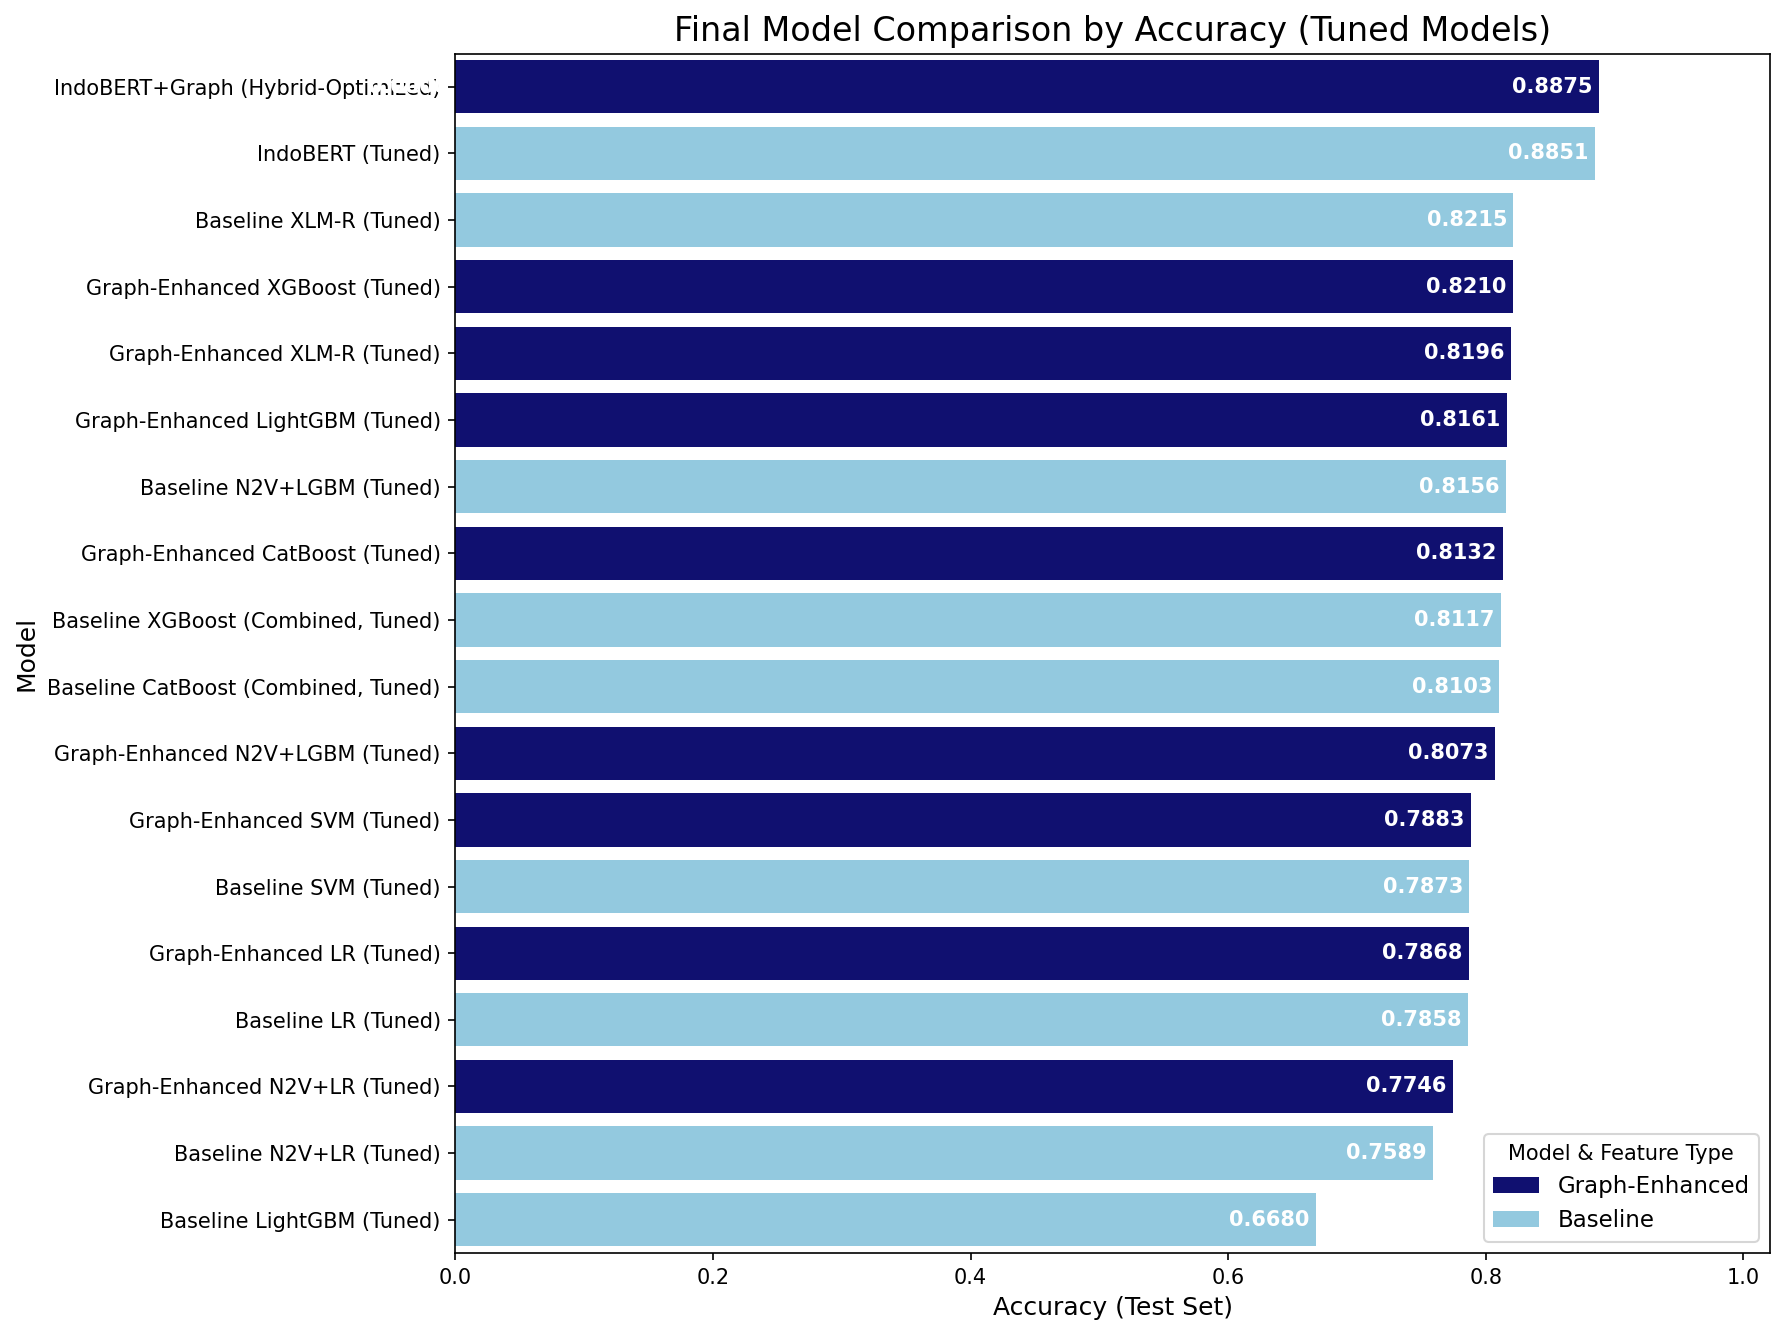

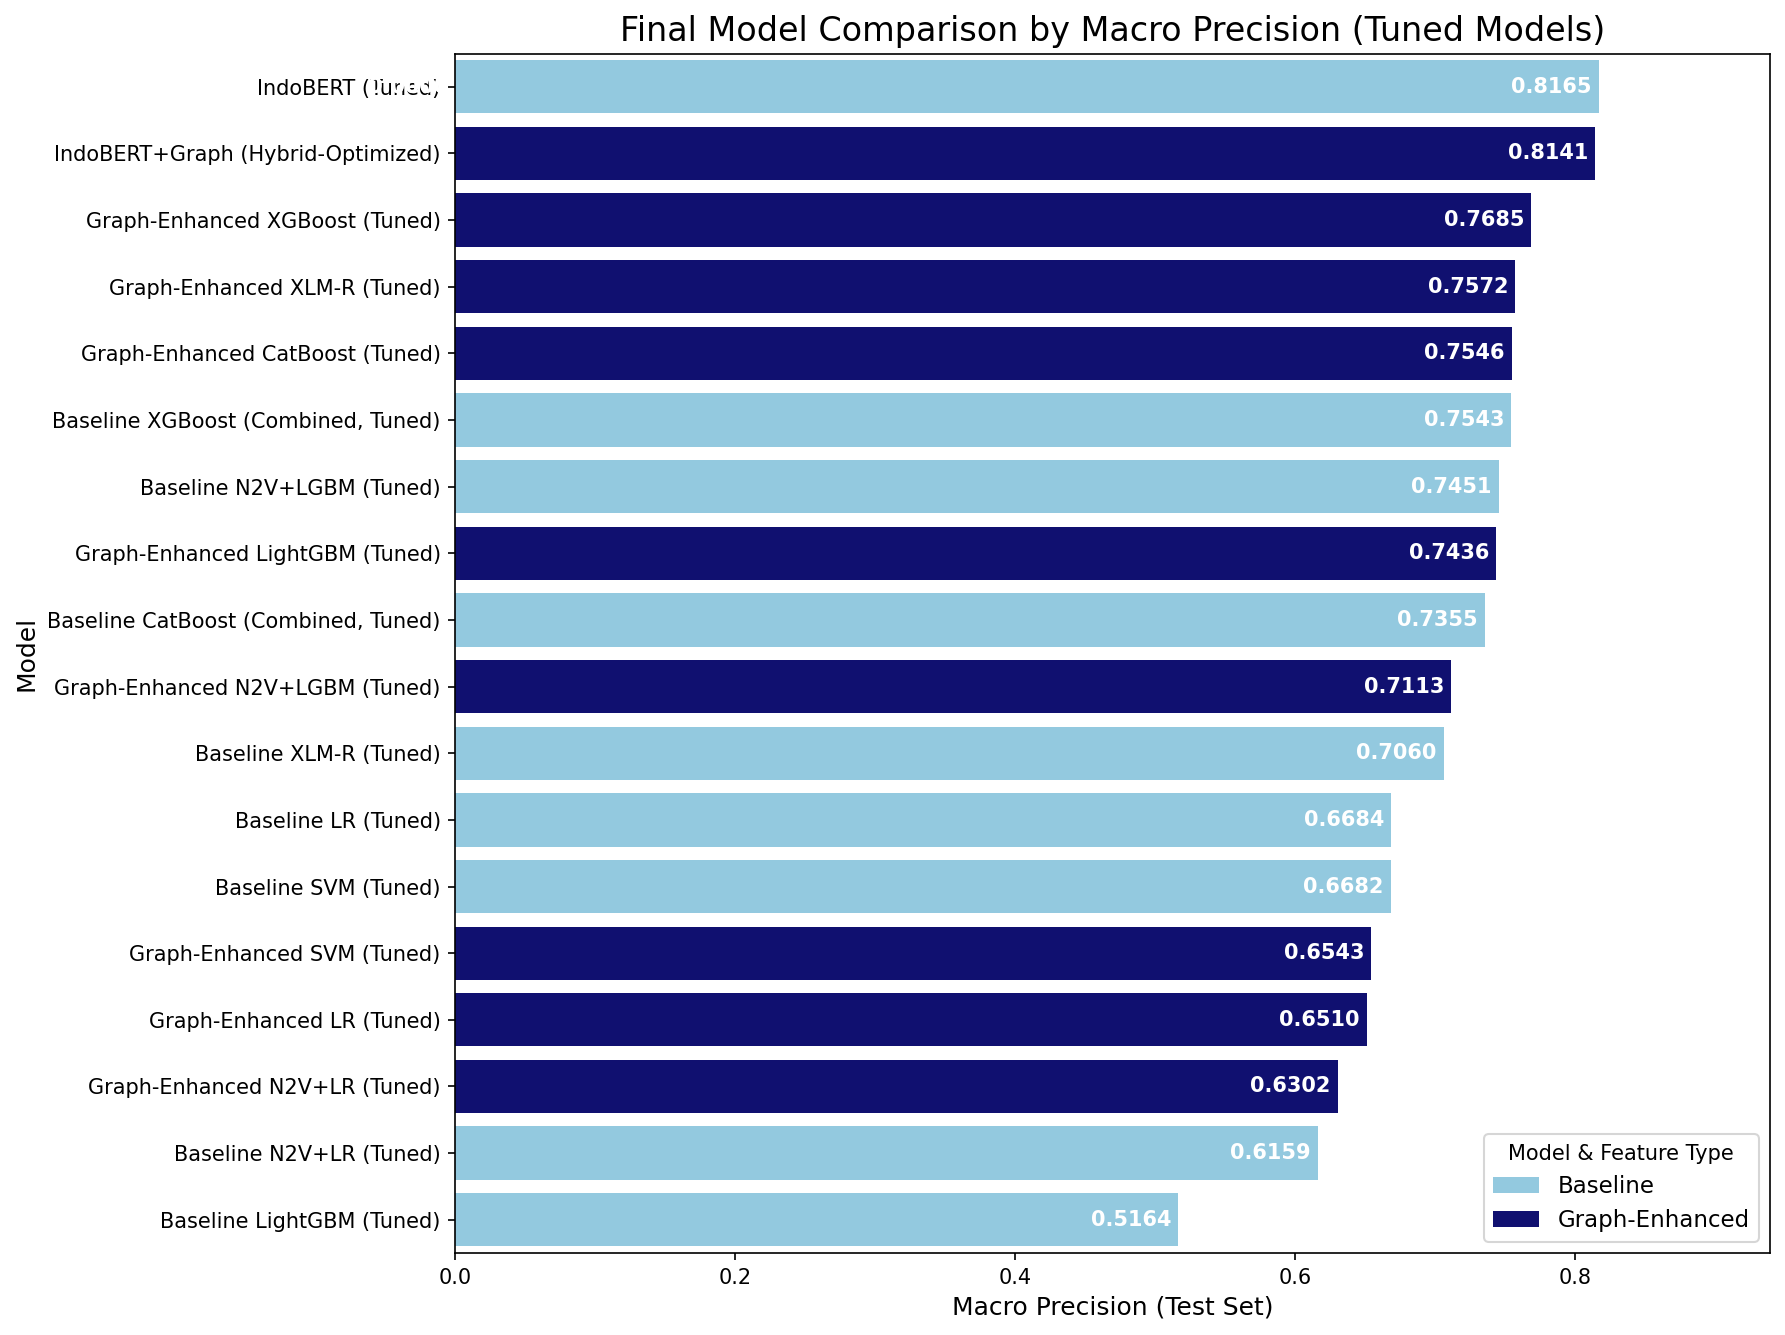

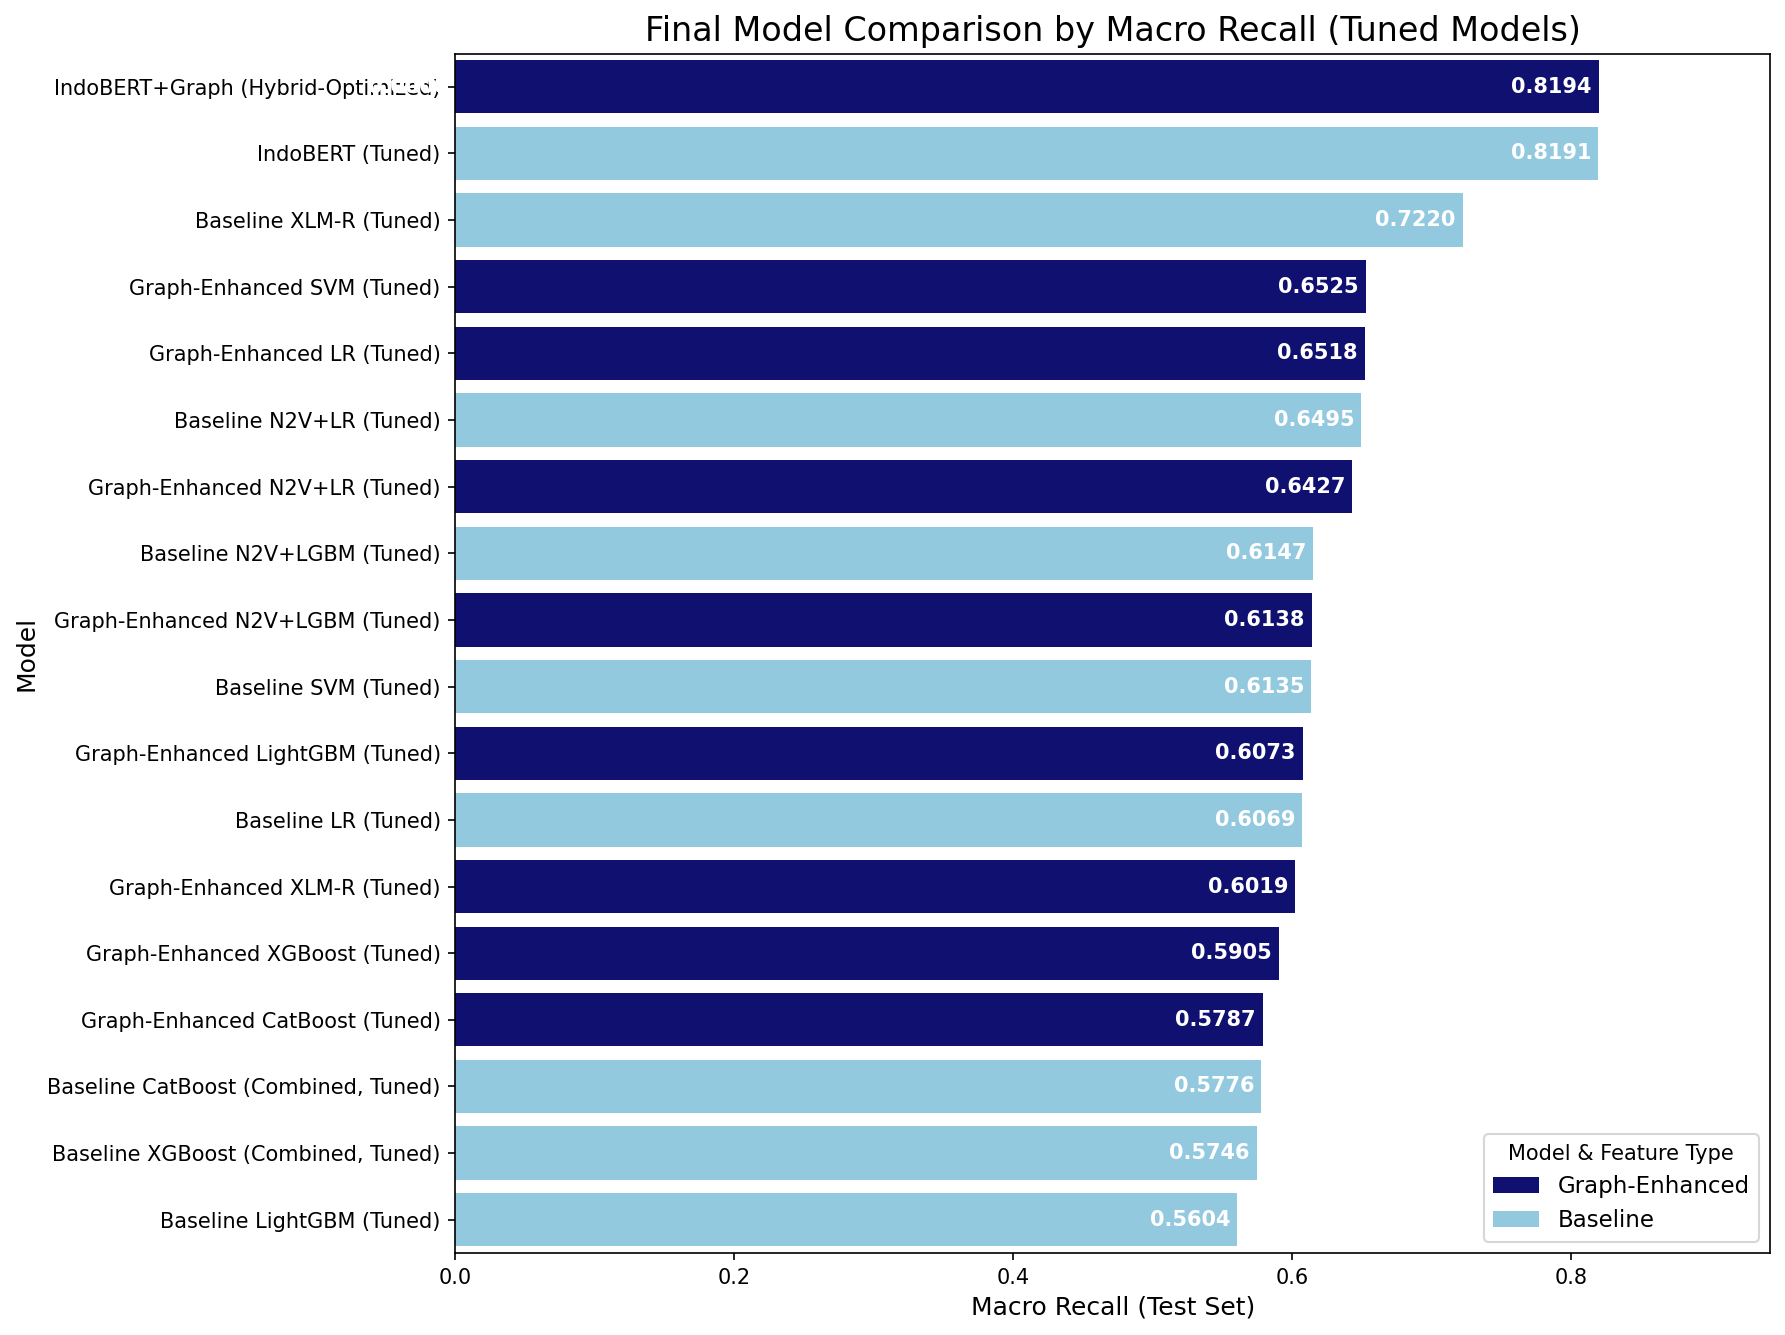

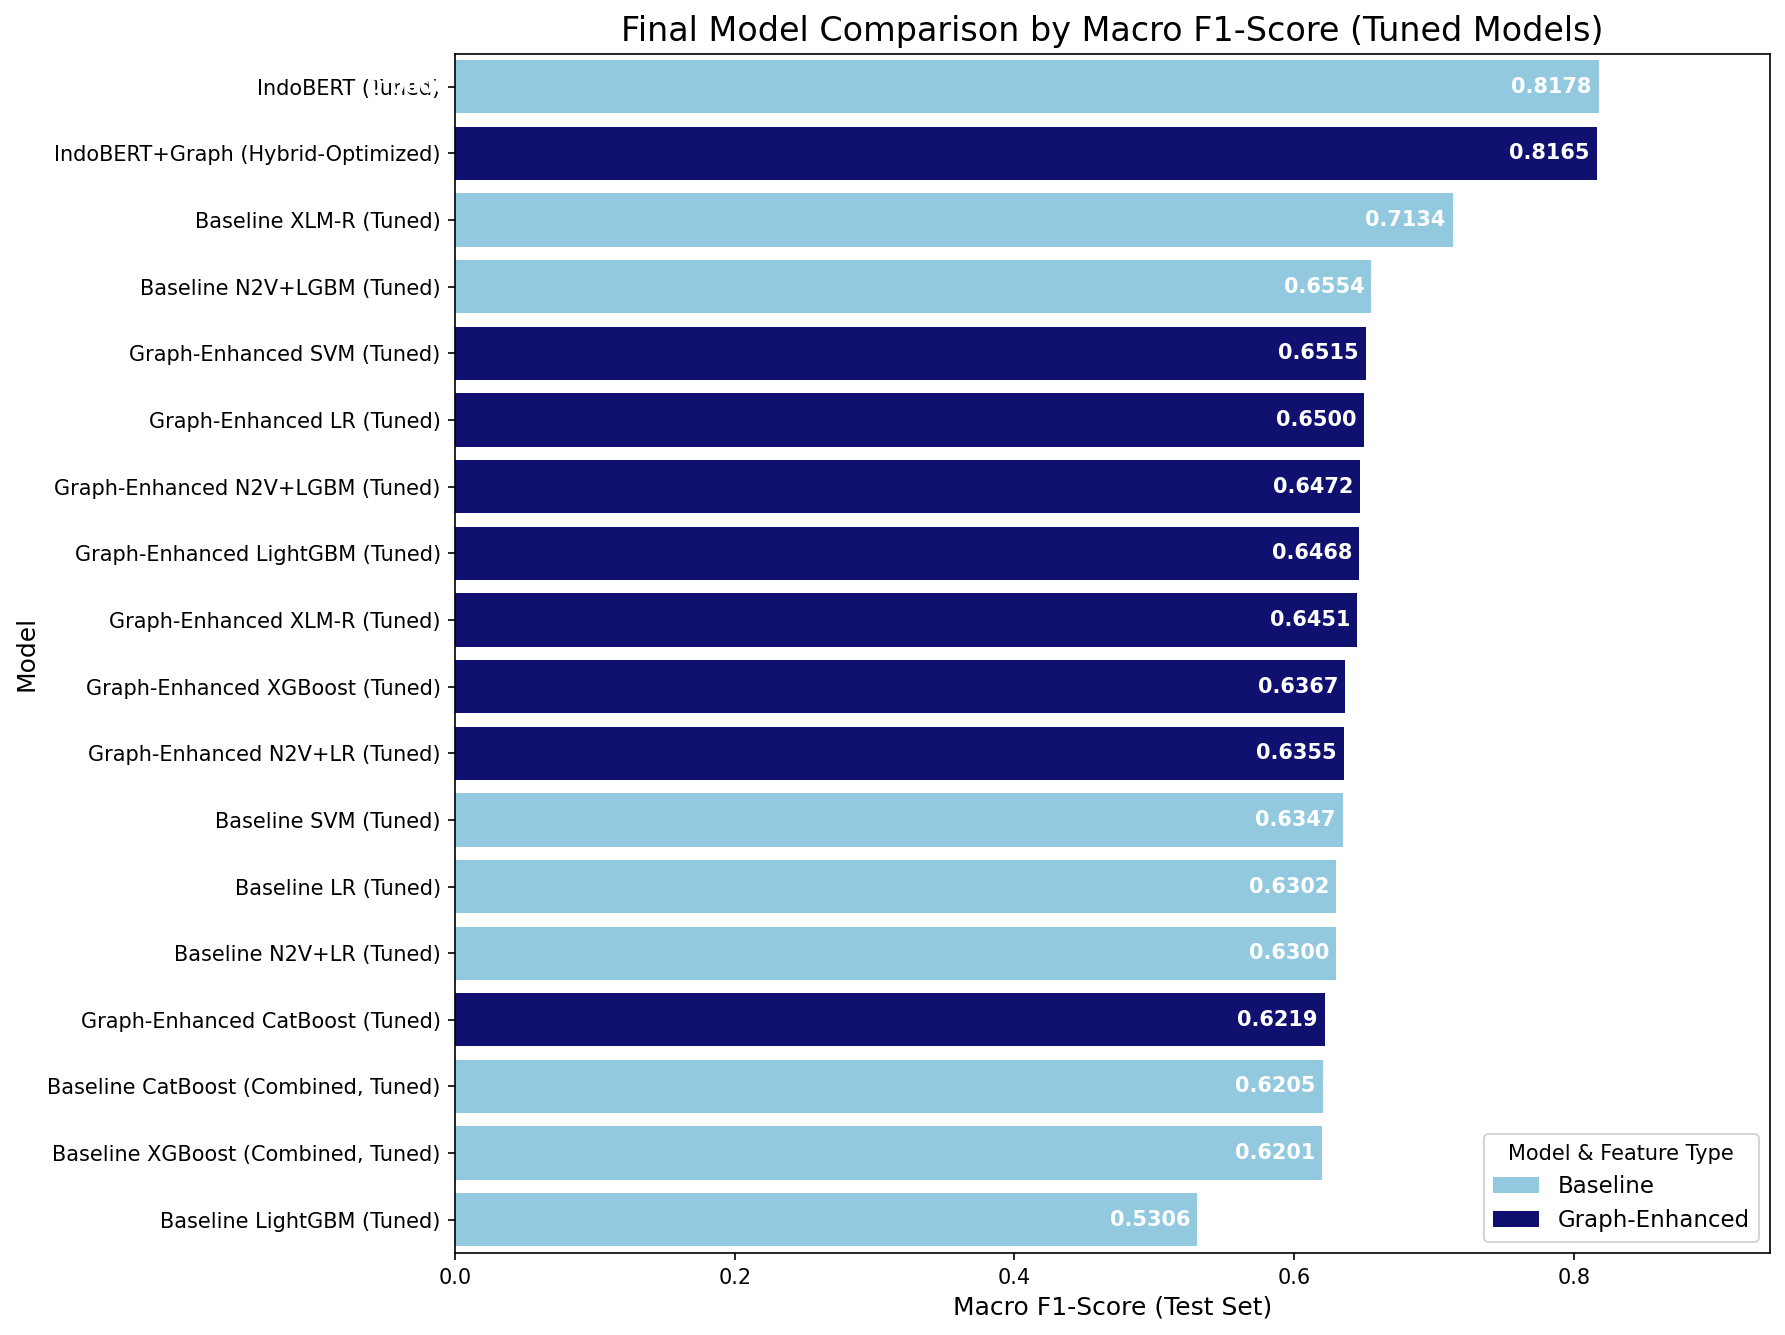

In [91]:
# ===================================================================
# CELL: VISUAL COMPARISON FOR ALL METRICS (FINAL & IMPROVED)
# ===================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# This cell visualizes the performance of the final tuned models across all four key metrics,
# grouping them by type to highlight the impact of graph features.

# --- FIX: Increase the resolution of the output plots for clarity ---
plt.rcParams['figure.dpi'] = 150
# -------------------------------------------------------------------

if 'tuned_models_df' in locals() and not tuned_models_df.empty:
    # List of metrics to plot
    metrics_to_plot = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score']

    for metric in metrics_to_plot:
        # Prepare data for plotting for the current metric
        plot_df = tuned_models_df.reset_index().copy()
        
        # --- FIX: Simplified categorization for a clearer "Before vs. After" story ---
        def categorize_model(model_name):
            # If it's a Graph-Enhanced model, it's in the experimental group.
            if "Graph-Enhanced" in model_name or "Hybrid" in model_name:
                return "Graph-Enhanced"
            # Everything else, including the text-only Transformers, is a baseline.
            else:
                return "Baseline"
        # -------------------------------------------------------------------
            
        plot_df['Model Type'] = plot_df['Model'].apply(categorize_model)
        
        # Ensure the metric column is numeric before sorting
        plot_df[metric] = pd.to_numeric(plot_df[metric])
        
        # Sort values for a clean chart, with the best model at the top
        plot_df = plot_df.sort_values(by=metric, ascending=False)

        # Create the plot
        plt.figure(figsize=(12, 9)) # Slightly adjusted size for better fit
        barplot = sns.barplot(
            x=metric,
            y='Model',
            data=plot_df,
            hue='Model Type',
            # --- FIX: Simplified color palette ---
            palette={'Baseline': 'skyblue', 'Graph-Enhanced': 'navy'},
            dodge=False
        )

        # Add data labels to the bars
        for bar in barplot.patches:
            score = bar.get_width()
            barplot.text(
                score - 0.005,
                bar.get_y() + bar.get_height() / 2,
                f"{score:.4f}",
                ha='right',
                va='center',
                color='white',
                weight='bold',
                size=10
            )

        plt.title(f'Final Model Comparison by {metric} (Tuned Models)', fontsize=16)
        plt.xlabel(f'{metric} (Test Set)', fontsize=12)
        plt.ylabel('Model', fontsize=12)
        plt.legend(title='Model & Feature Type', fontsize=11)
        plt.xlim(0, max(plot_df[metric]) * 1.15)
        plt.tight_layout()
        plt.show()

else:
    print("Please run the summary table cell before running this visualization cell.")

---
## Deployment
---

In [54]:
# ===================================================================
# CELL: SAVE FINAL HYBRID MODEL AND ASSETS FOR DEPLOYMENT
# ===================================================================
import os
import torch
import joblib

# Define paths
project_root = "C:\\Users\\soozh\\AAAfyp" # Use your specific project path
save_directory = os.path.join(project_root, "results", "best_hybrid_model")
scaler_path = os.path.join(project_root, "results", "lean_scaler.joblib")
token_properties_path = os.path.join(project_root, "results", "token_properties.joblib")

print(f"Saving assets for deployment...")
os.makedirs(save_directory, exist_ok=True)

# 1. Save the Model's State Dictionary
# The best model is held by the trainer after the search
best_model = final_trainer.model
torch.save(best_model.state_dict(), os.path.join(save_directory, "pytorch_model.bin"))

# 2. Save the Feature Scaler
# The 'scaler_lean' object was created in the cell that prepared the lean features
joblib.dump(scaler_lean, scaler_path)

# 3. Save the Token Properties Lookup (for generating graph features for new text)
# We can create this from the algorithmic scores calculated in the feature engineering cell
token_properties = {
    'pagerank': pagerank_scores,
    'degree': degree_scores,
    'betweenness': betweenness_scores
}
joblib.dump(token_properties, token_properties_path)

print(f"Model state_dict saved to: {save_directory}")
print(f"Scaler saved to: {scaler_path}")
print(f"Token properties saved to: {token_properties_path}")
print("All assets saved successfully.")

Saving assets for deployment...
Model state_dict saved to: C:\Users\soozh\AAAfyp\results\best_hybrid_model
Scaler saved to: C:\Users\soozh\AAAfyp\results\lean_scaler.joblib
Token properties saved to: C:\Users\soozh\AAAfyp\results\token_properties.joblib
All assets saved successfully.
